In [105]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [106]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00         SAO   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00         SAO   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00         SAO   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00         SAO   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00         SAO   
...               ...       ...        ...                  ...         ...   
14495830  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
14495831  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
14495832  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
14495833  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
14495834  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

          HourlyDewPointTemperature  HourlyDryBulbT

In [107]:
# Exclude days from April through October (months 4-10) in CV_rows
CV_rows = CV_rows[~CV_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_rows after removing April-October:", CV_rows.shape)

CV_rows after removing April-October: (6404926, 19)


In [108]:
CV_rows['HourlyDewpointDepression'] = (
    CV_rows['HourlyDryBulbTemperature'] - CV_rows['HourlyDewPointTemperature']
)

CV_rows[['HourlyDryBulbTemperature', 'HourlyDewPointTemperature', 'HourlyDewpointDepression']].head()

,HourlyDryBulbTemperature,HourlyDewPointTemperature,HourlyDewpointDepression
0,13.0,11.9,1.1
1,12.4,10.7,1.7
2,12.4,11.3,1.1
3,12.4,11.3,1.1
4,13.0,11.9,1.1


In [109]:
# Ensure wind direction is numeric; "000" is treated as calm (0, 0)
wd1 = pd.to_numeric(CV_rows["HourlyWindDirection"], errors="coerce")

# Unit-vector style components from wind direction
# 360 = north, 180 = south, 270 = west, 90 = east
# Determine the north-south component of the wind direction
CV_rows["wind_ns_component"] = np.where(
    wd1.eq(0) | wd1.isna(),
    0.0,
    np.cos(np.deg2rad(wd1))
)

# Determine west-east component of the wind direction
CV_rows["wind_we_component"] = np.where(
    wd1.eq(0) | wd1.isna(),
    0.0,
    np.sin(np.deg2rad(wd1))
)

CV_rows[["HourlyWindDirection", "wind_ns_component", "wind_we_component"]].head()

,HourlyWindDirection,wind_ns_component,wind_we_component
0,0.0,0.000000,0.000000
1,158.0,-0.927184,0.374607
2,0.0,0.000000,0.000000
3,225.0,-0.707107,-0.707107
4,225.0,-0.707107,-0.707107


In [110]:
# Classify each observation as up-valley or down-valley relative to valley angle = 330°
valley_angle = 330.0  # interpreted as the up-valley flow direction (toward 330°)

wd = pd.to_numeric(CV_rows["HourlyWindDirection"], errors="coerce")  # meteorological "from" direction
ws = pd.to_numeric(CV_rows["HourlyWindSpeed"], errors="coerce")

# Convert to "to" direction (direction wind is blowing toward)
wd_to = (wd + 180.0) % 360.0

# Signed alignment with valley axis (+ up-valley, - down-valley)
# cos(delta) > 0 means aligned with up-valley axis, < 0 means opposite (down-valley)
delta = np.deg2rad(wd_to - valley_angle)
valley_alignment = np.cos(delta)

# Optional speed-weighted along-valley component
CV_rows["valley_along_component"] = valley_alignment * ws

calm_mask = wd.eq(0) | ws.eq(0)  # "000" direction and/or zero speed => calm
missing_mask = wd.isna() | ws.isna()

# Classify each observation as "up_valley", "down_valley", "cross_valley", "calm", or "missing"
CV_rows["valley_wind_type"] = np.select(
    [
        missing_mask,
        calm_mask,
        valley_alignment > 0,
        valley_alignment < 0,
    ],
    [
        "missing",
        "calm",
        "up_valley",
        "down_valley",
    ],
    default="cross_valley",
)

# Quick station-level check of the counts of each valley wind type
station_valley_counts = (
    CV_rows.groupby(["STATION", "valley_wind_type"])
    .size()
    .unstack(fill_value=0)
)

station_valley_counts.head()

valley_wind_type,calm,down_valley,up_valley
STATION,,,
BAKERSFIELD AP,93181,160509,132605
BEALE AFB,70007,94808,152317
CASTLE AFB,124287,88552,89316
CHICO ARMY FLYING SCHOOL,61822,61995,74061
FRESNO,1350,13684,9917


In [111]:
# Print all column names from CV_rows

CV_rows.head()

,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyPresentWeatherType,HourlySkyConditions,...,month,day,hour,minute,STATION,HourlyDewpointDepression,wind_ns_component,wind_we_component,valley_along_component,valley_wind_type
0,USM00074917,35.117,-119.3,1941-12-01 00:00:00,SAO,11.9,13.0,0.0,||00,BKN:06,...,12,1,0,0,GARDNER AAF,1.1,0.000000,0.000000,-0.000000,calm
1,USM00074917,35.117,-119.3,1941-12-01 01:00:00,SAO,10.7,12.4,0.0,||00,OVC:08,...,12,1,1,0,GARDNER AAF,1.7,-0.927184,0.374607,0.495134,up_valley
2,USM00074917,35.117,-119.3,1941-12-01 02:00:00,SAO,11.3,12.4,0.0,||00,OVC:08,...,12,1,2,0,GARDNER AAF,1.1,0.000000,0.000000,-0.000000,calm
3,USM00074917,35.117,-119.3,1941-12-01 03:00:00,SAO,11.3,12.4,0.0,||00,OVC:08,...,12,1,3,0,GARDNER AAF,1.1,-0.707107,-0.707107,0.129410,up_valley
4,USM00074917,35.117,-119.3,1941-12-01 04:00:00,SAO,11.9,13.0,0.0,||00,OVC:08,...,12,1,4,0,GARDNER AAF,1.1,-0.707107,-0.707107,0.129410,up_valley


In [112]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_wind_filtered = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 4.6)
    & (CV_rows["HourlyWindSpeed"] < 2.000)
]

print("CV_filtered_rows:", CV_rows_dd_wind_filtered.shape)

CV_filtered_rows: (1750733, 24)


In [113]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_5deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 4.6)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_5deg.shape)

CV_filtered_rows: (246441, 24)


In [114]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_4deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 4)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_4deg.shape)

CV_filtered_rows: (245852, 24)


In [115]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_3deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 3)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_3deg.shape)

CV_filtered_rows: (242934, 24)


In [116]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_2deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 2)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_2deg.shape)

CV_filtered_rows: (233179, 24)


In [117]:
# filtering based on precipitation
# filtering visibility threshold to identify outliers
CV_rows_dd_filtered_1deg = CV_rows[
    (CV_rows["HourlyDewpointDepression"] < 1)
    & (CV_rows["HourlyVisibility"] < 1.000)
]

print("CV_filtered_rows:", CV_rows_dd_filtered_1deg.shape)

CV_filtered_rows: (181694, 24)


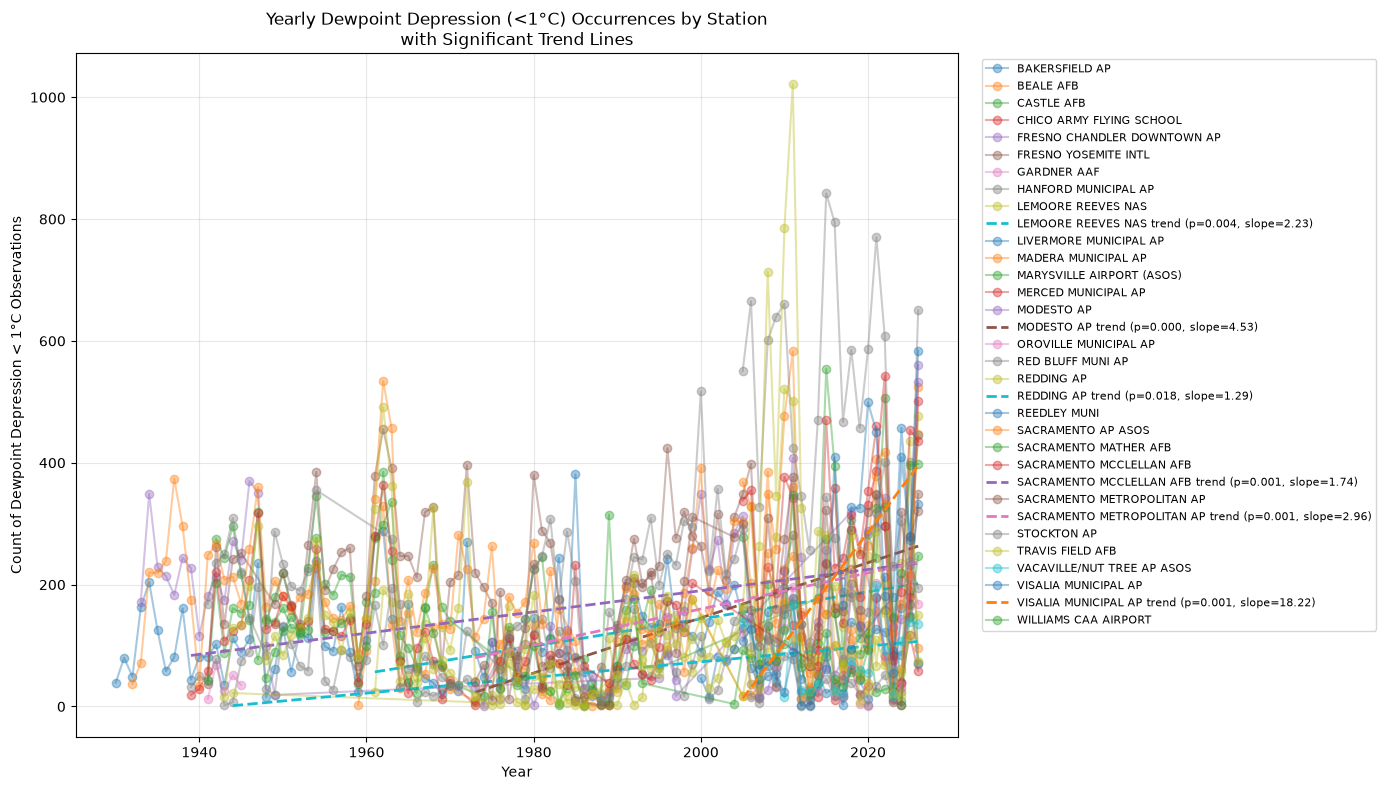

In [118]:
# Plot dewpoint depression occurrences per year for each station (CV_rows_dd_filtered_1deg)
# Fit and plot trend lines only for stations with statistically significant trends (p < 0.05)

yearly_counts = (
    CV_rows_dd_filtered_1deg.groupby(["STATION", "year"])
    .size()
    .reset_index(name="count")
)

stations = yearly_counts["STATION"].unique()

fig, ax = plt.subplots(figsize=(14, 8))

for station in stations:
    station_data = yearly_counts[yearly_counts["STATION"] == station].sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].values
    y = station_data["count"].values

    # Plot the raw yearly counts
    ax.plot(x, y, marker='o', linestyle='-', alpha=0.4, label=f"{station}")

    # Fit linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # Only plot trend line if significant (p < 0.05)
    if p_value < 0.05:
        trend_y = slope * x + intercept
        ax.plot(x, trend_y, linestyle='--', linewidth=2,
                label=f"{station} trend (p={p_value:.3f}, slope={slope:.2f})")

ax.set_xlabel("Year")
ax.set_ylabel("Count of Dewpoint Depression < 1°C Observations")
ax.set_title("Yearly Dewpoint Depression (<1°C) Occurrences by Station\nwith Significant Trend Lines")
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

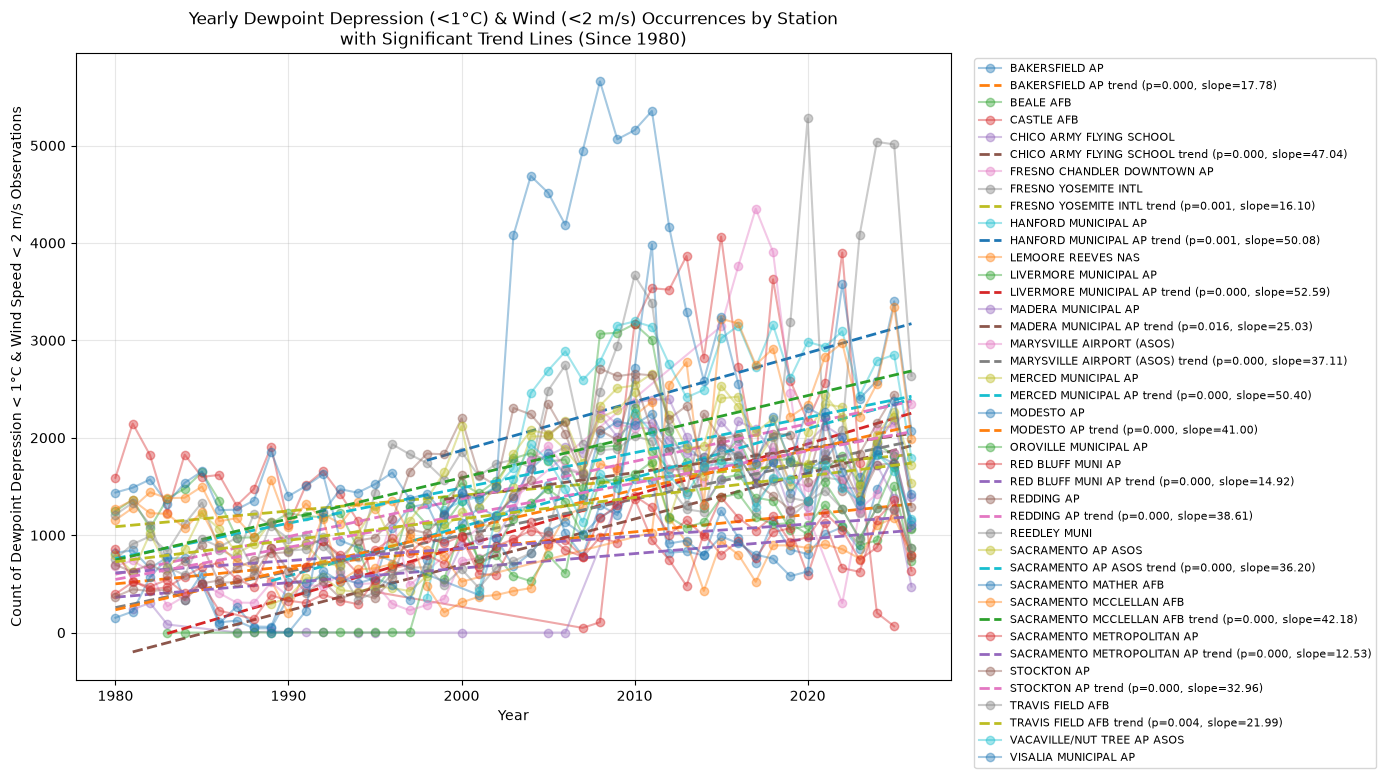

In [119]:
# Plot dewpoint depression occurrences per year for each station (CV_rows_dd_wind_filtered)
# Fit and plot trend lines only for stations with statistically significant trends (p < 0.05), since 1980

yearly_counts_wind = (
    CV_rows_dd_wind_filtered[CV_rows_dd_wind_filtered['year'] >= 1980]
    .groupby(["STATION", "year"])
    .size()
    .reset_index(name="count")
)

stations_wind = yearly_counts_wind["STATION"].unique()

fig, ax = plt.subplots(figsize=(14, 8))

for station in stations_wind:
    station_data = yearly_counts_wind[yearly_counts_wind["STATION"] == station].sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].values
    y = station_data["count"].values

    # Plot the raw yearly counts
    ax.plot(x, y, marker='o', linestyle='-', alpha=0.4, label=f"{station}")

    # Fit linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # Only plot trend line if significant (p < 0.05)
    if p_value < 0.05:
        trend_y = slope * x + intercept
        ax.plot(x, trend_y, linestyle='--', linewidth=2,
                label=f"{station} trend (p={p_value:.3f}, slope={slope:.2f})")

ax.set_xlabel("Year")
ax.set_ylabel("Count of Dewpoint Depression < 1°C & Wind Speed < 2 m/s Observations")
ax.set_title("Yearly Dewpoint Depression (<1°C) & Wind (<2 m/s) Occurrences by Station\nwith Significant Trend Lines (Since 1980)")
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [120]:
# Compare CV_rows to CV_rows_dd_wind_filtered to determine the number of days/observations with optimal fog conditions
total_obs = CV_rows.shape[0]
optimal_obs = CV_rows_dd_wind_filtered.shape[0]

print(f"Total observations: {total_obs}")
print(f"Observations with optimal fog conditions (dewpoint depression < 4.6 & wind speed < 2 m/s): {optimal_obs}")
print(f"Percentage of optimal fog condition observations: {optimal_obs / total_obs * 100:.2f}%")

# Count unique days (based on year, month, day) with at least one optimal fog observation
optimal_days = CV_rows_dd_wind_filtered[["STATION","year", "month", "day"]].drop_duplicates().shape[0]
total_days = CV_rows[["STATION","year", "month", "day"]].drop_duplicates().shape[0]

print(f"\nTotal unique days in dataset: {total_days}")
print(f"Unique days with at least one optimal fog condition observation: {optimal_days}")
print(f"Percentage of days with optimal fog conditions: {optimal_days / total_days * 100:.2f}%")

Total observations: 6404926
Observations with optimal fog conditions (dewpoint depression < 4.6 & wind speed < 2 m/s): 1750733
Percentage of optimal fog condition observations: 27.33%

Total unique days in dataset: 260520
Unique days with at least one optimal fog condition observation: 171480
Percentage of days with optimal fog conditions: 65.82%


In [121]:
# Fraction of rows in the optimal fog dataset that have visibility < 1
optimal_rows = CV_rows_dd_wind_filtered.copy()

vis_lt_1_rows = optimal_rows[optimal_rows["HourlyVisibility"] < 1].copy()
frac_rows_vis_lt_1 = vis_lt_1_rows.shape[0] / optimal_rows.shape[0]

# Compare to total unique days with optimal fog conditions
total_optimal_days = optimal_rows[["STATION", "year", "month", "day"]].drop_duplicates().shape[0]
vis_lt_1_days = vis_lt_1_rows[["STATION", "year", "month", "day"]].drop_duplicates().shape[0]
frac_days_vis_lt_1 = vis_lt_1_days / total_optimal_days

print(f"Optimal-fog rows with visibility < 1: {vis_lt_1_rows.shape[0]} / {optimal_rows.shape[0]} = {frac_rows_vis_lt_1:.2%}")
print(f"Optimal-fog days with visibility < 1: {vis_lt_1_days} / {total_optimal_days} = {frac_days_vis_lt_1:.2%}")

# Optional: also compare directly to the previously computed total optimal fog days variable, if present
if "optimal_days" in globals():
    print(f"Previous total optimal fog days variable: {optimal_days}")
    print(f"Ratio of visibility<1 days to prior optimal_days: {vis_lt_1_days / optimal_days:.2%}")

Optimal-fog rows with visibility < 1: 165573 / 1750733 = 9.46%
Optimal-fog days with visibility < 1: 27948 / 171480 = 16.30%
Previous total optimal fog days variable: 171480
Ratio of visibility<1 days to prior optimal_days: 16.30%


In [122]:
# Repeat the fog analysis for only the FRESNO YOSEMITE INTL and SACRAMENTO AP ASOS stations

station_names = ["BAKERSFIELD AP", "FRESNO YOSEMITE INTL", "RED BLUFF MUNI AP", "SACRAMENTO AP ASOS", "STOCKTON AP", "TRAVIS FIELD AFB"]

# Restrict the full dataset to the selected stations
CV_rows_selected = CV_rows[CV_rows["STATION"].isin(station_names)].copy()

# Ensure dewpoint depression exists
if "HourlyDewpointDepression" not in CV_rows_selected.columns:
    CV_rows_selected["HourlyDewpointDepression"] = (
        CV_rows_selected["HourlyDryBulbTemperature"] - CV_rows_selected["HourlyDewPointTemperature"]
    )

print("Selected station rows:", CV_rows_selected.shape)
print(CV_rows_selected["STATION"].value_counts())

# ------------------------------------------------------------------
# Optimal fog condition filter: dewpoint depression < 4.6 and wind < 2
# ------------------------------------------------------------------
CV_rows_selected_dd_wind_filtered = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 4.6)
    & (CV_rows_selected["HourlyWindSpeed"] < 2.0)
].copy()

CV_rows_selected_dd_wind_filtered = CV_rows_selected_dd_wind_filtered.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")

print("\nOptimal fog condition rows (DD < 4.6 & wind < 2 m/s):", CV_rows_selected_dd_wind_filtered.shape)

CV_rows_selected_dd_wind5_filtered = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 2.0)
    & (CV_rows_selected["HourlyWindSpeed"] < 5.0)
].copy()

CV_rows_selected_dd_wind5_filtered = CV_rows_selected_dd_wind5_filtered.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")

print("\nOptimal fog condition rows (DD < 2.0 & wind < 5 m/s):", CV_rows_selected_dd_wind5_filtered.shape)

# ------------------------------------------------------------------
# Visibility-based filters for multiple thresholds
# ------------------------------------------------------------------
CV_rows_selected_dd_filtered_5deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 5.0)
    # & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_4deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 4.0)
    # & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_3deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 3.0)
    # & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_2deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 2.0)
    # & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_1deg = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 1.0)
    # & (CV_rows_selected["HourlyVisibility"] < 1.0)
].copy()

CV_rows_selected_dd_filtered_5deg = CV_rows_selected_dd_filtered_5deg.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")
CV_rows_selected_dd_filtered_4deg = CV_rows_selected_dd_filtered_4deg.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")
CV_rows_selected_dd_filtered_3deg = CV_rows_selected_dd_filtered_3deg.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")
CV_rows_selected_dd_filtered_2deg = CV_rows_selected_dd_filtered_2deg.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")
CV_rows_selected_dd_filtered_1deg = CV_rows_selected_dd_filtered_1deg.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")

for name, df in {
    "CV_rows_selected_dd_filtered_5deg": CV_rows_selected_dd_filtered_5deg,
    "CV_rows_selected_dd_filtered_4deg": CV_rows_selected_dd_filtered_4deg,
    "CV_rows_selected_dd_filtered_3deg": CV_rows_selected_dd_filtered_3deg,
    "CV_rows_selected_dd_filtered_2deg": CV_rows_selected_dd_filtered_2deg,
    "CV_rows_selected_dd_filtered_1deg": CV_rows_selected_dd_filtered_1deg,
}.items():
    print(f"\n{name}: {df.shape}")

# ------------------------------------------------------------------
# Station-level valley wind type summary
# ------------------------------------------------------------------
selected_valley_counts = (
    CV_rows_selected.groupby(["STATION", "valley_wind_type"])
    .size()
    .unstack(fill_value=0)
)

print("\nSelected station valley wind counts:")
print(selected_valley_counts)


Selected station rows: (2269546, 24)
STATION
TRAVIS FIELD AFB        412534
SACRAMENTO AP ASOS      403780
BAKERSFIELD AP          386295
FRESNO YOSEMITE INTL    363973
RED BLUFF MUNI AP       359261
STOCKTON AP             343703
Name: count, dtype: int64

Optimal fog condition rows (DD < 4.6 & wind < 2 m/s): (419624, 24)

Optimal fog condition rows (DD < 2.0 & wind < 5 m/s): (507493, 24)

CV_rows_selected_dd_filtered_5deg: (1086197, 24)

CV_rows_selected_dd_filtered_4deg: (1002380, 24)

CV_rows_selected_dd_filtered_3deg: (821904, 24)

CV_rows_selected_dd_filtered_2deg: (571330, 24)

CV_rows_selected_dd_filtered_1deg: (247976, 24)

Selected station valley wind counts:
valley_wind_type        calm  down_valley  up_valley
STATION                                             
BAKERSFIELD AP         93181       160509     132605
FRESNO YOSEMITE INTL   94708       121321     147944
RED BLUFF MUNI AP      54518       186227     118516
SACRAMENTO AP ASOS    109273       123407     171100
STOC

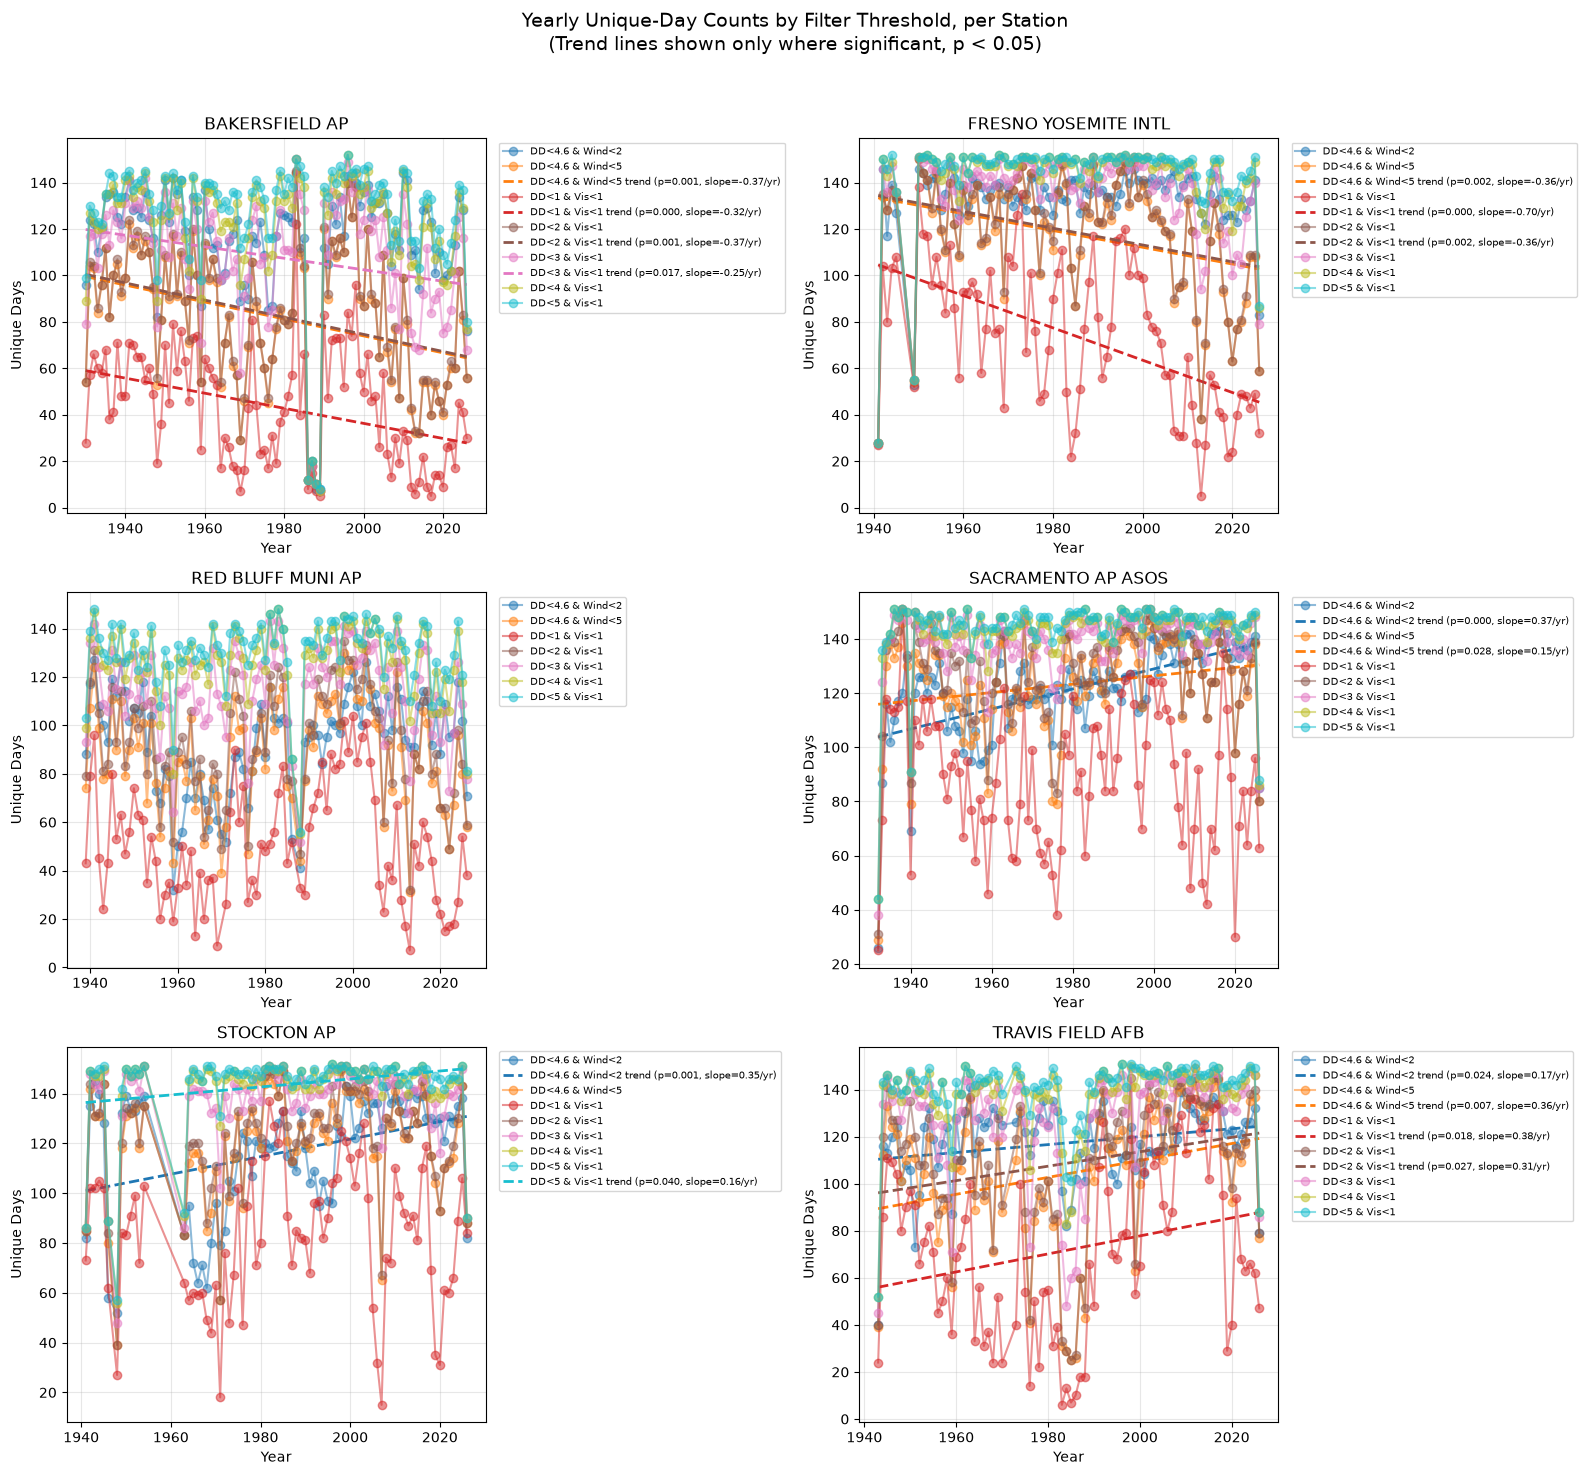

In [123]:
# Individual per-station plots: yearly unique-day counts for multiple dewpoint-depression/visibility
# filters, with significant (p < 0.05) trend lines only

filters_to_plot = {
    "DD<4.6 & Wind<2": CV_rows_selected_dd_wind_filtered,
    "DD<4.6 & Wind<5": CV_rows_selected_dd_wind5_filtered,
    "DD<1 & Vis<1": CV_rows_selected_dd_filtered_1deg,
    "DD<2 & Vis<1": CV_rows_selected_dd_filtered_2deg,
    "DD<3 & Vis<1": CV_rows_selected_dd_filtered_3deg,
    "DD<4 & Vis<1": CV_rows_selected_dd_filtered_4deg,
    "DD<5 & Vis<1": CV_rows_selected_dd_filtered_5deg,
}

colors = plt.cm.tab10(np.linspace(0, 1, len(filters_to_plot)))

n_stations = len(station_names)
n_cols = 2
n_rows = int(np.ceil(n_stations / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows), sharex=False)
axes = axes.flatten()

for i, station in enumerate(station_names):
    ax = axes[i]

    for (label, df), color in zip(filters_to_plot.items(), colors):
        station_df = df[df["STATION"] == station]

        # unique days per year
        yearly_days = (
            station_df[["year", "month", "day"]]
            .drop_duplicates()
            .groupby("year")
            .size()
            .reset_index(name="count")
            .sort_values("year")
        )

        if len(yearly_days) < 3:
            continue

        x = yearly_days["year"].to_numpy()
        y = yearly_days["count"].to_numpy()

        ax.plot(x, y, marker="o", linestyle="-", alpha=0.5, color=color, label=label)

        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        if np.isfinite(p_value) and p_value < 0.05:
            trend_y = slope * x + intercept
            ax.plot(
                x, trend_y, linestyle="--", linewidth=2, color=color,
                label=f"{label} trend (p={p_value:.3f}, slope={slope:.2f}/yr)"
            )

    ax.set_title(station)
    ax.set_xlabel("Year")
    ax.set_ylabel("Unique Days")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1))

for j in range(n_stations, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Yearly Unique-Day Counts by Filter Threshold, per Station\n"
    "(Trend lines shown only where significant, p < 0.05)",
    fontsize=14,
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

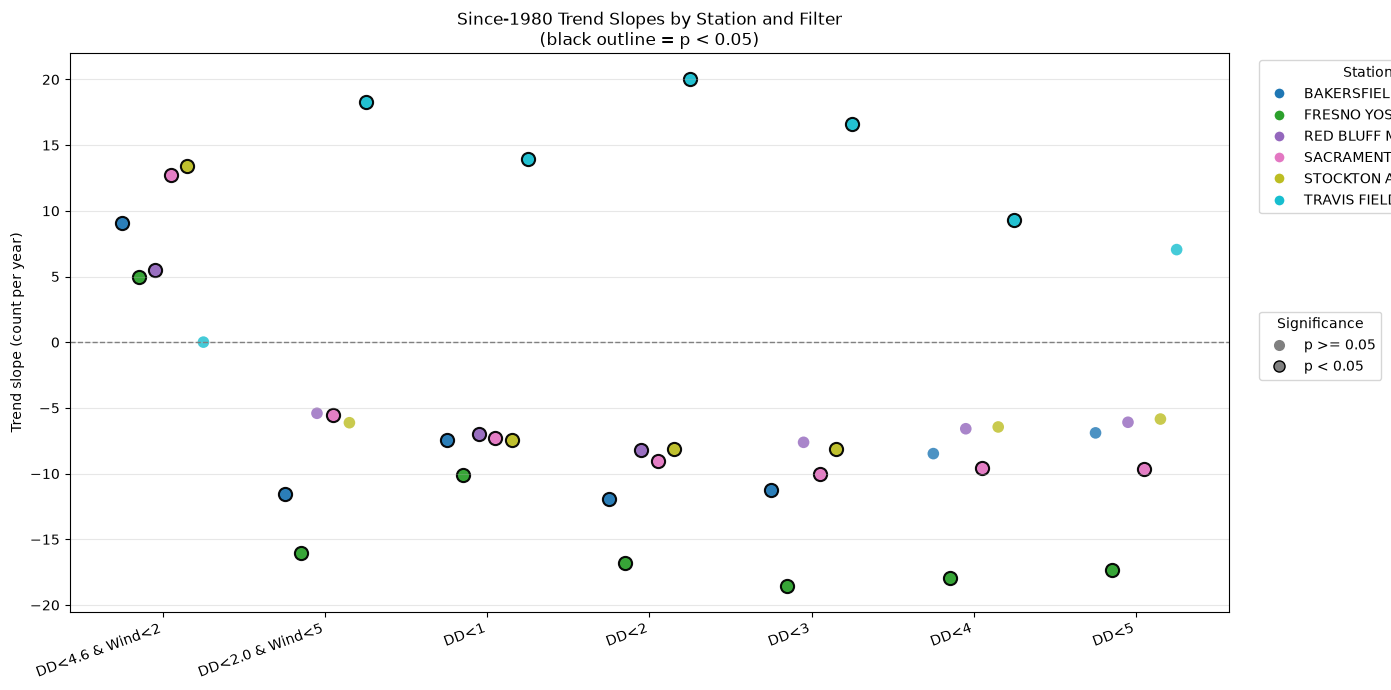

,filter,STATION,slope_per_year,p_value,significant
13,DD<1,FRESNO YOSEMITE INTL,-10.099098,9.916167e-05,True
12,DD<1,BAKERSFIELD AP,-7.416166,2.209023e-04,True
14,DD<1,RED BLUFF MUNI AP,-7.004764,7.435799e-03,True
17,DD<1,TRAVIS FIELD AFB,13.919635,1.170755e-02,True
16,DD<1,STOCKTON AP,-7.445999,1.741935e-02,True
15,DD<1,SACRAMENTO AP ASOS,-7.312673,2.102774e-02,True
19,DD<2,FRESNO YOSEMITE INTL,-16.825162,2.358257e-06,True
23,DD<2,TRAVIS FIELD AFB,20.053307,1.902608e-04,True
18,DD<2,BAKERSFIELD AP,-11.942183,2.223625e-03,True
21,DD<2,SACRAMENTO AP ASOS,-9.001735,3.418895e-03,True


In [124]:
# Trend summary plot since 1980:
# one point per (station, filter) showing slope of yearly counts vs year.
# Station = color, significant trend (p < 0.05) = black outline.

filters_for_trend = {
    "DD<4.6 & Wind<2": CV_rows_selected_dd_wind_filtered,
    "DD<2.0 & Wind<5": CV_rows_selected_dd_wind5_filtered,
    "DD<1": CV_rows_selected_dd_filtered_1deg,
    "DD<2": CV_rows_selected_dd_filtered_2deg,
    "DD<3": CV_rows_selected_dd_filtered_3deg,
    "DD<4": CV_rows_selected_dd_filtered_4deg,
    "DD<5": CV_rows_selected_dd_filtered_5deg,
}

trend_points = []

for filter_name, df_filter in filters_for_trend.items():
    yearly = (
        df_filter[df_filter["year"] >= 1980]
        .groupby(["STATION", "year"])
        .size()
        .reset_index(name="count")
    )

    for st in station_names:
        sd = yearly[yearly["STATION"] == st].sort_values("year")
        if len(sd) < 3:
            continue

        x = sd["year"].to_numpy()
        y = sd["count"].to_numpy()
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        trend_points.append(
            {
                "filter": filter_name,
                "STATION": st,
                "slope_per_year": slope,
                "p_value": p_value,
                "significant": bool(np.isfinite(p_value) and (p_value < 0.05)),
            }
        )

trend_points_df = pd.DataFrame(trend_points)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

filter_order = list(filters_for_trend.keys())
x_map = {f: i for i, f in enumerate(filter_order)}

station_colors = dict(zip(station_names, plt.cm.tab10(np.linspace(0, 1, len(station_names)))))
offsets = np.linspace(-0.25, 0.25, len(station_names))
station_offset = dict(zip(station_names, offsets))

for st in station_names:
    sub = trend_points_df[trend_points_df["STATION"] == st].copy()
    if sub.empty:
        continue

    sub["x"] = sub["filter"].map(x_map).astype(float) + station_offset[st]

    # non-significant points
    ns = sub[~sub["significant"]]
    ax.scatter(
        ns["x"], ns["slope_per_year"],
        s=70, color=station_colors[st], alpha=0.8,
        edgecolors="none"
    )

    # significant points with black outline
    sg = sub[sub["significant"]]
    ax.scatter(
        sg["x"], sg["slope_per_year"],
        s=90, color=station_colors[st], alpha=0.95,
        edgecolors="black", linewidths=1.5
    )

# style
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(range(len(filter_order)))
ax.set_xticklabels(filter_order, rotation=20, ha="right")
ax.set_ylabel("Trend slope (count per year)")
ax.set_title("Since-1980 Trend Slopes by Station and Filter\n(black outline = p < 0.05)")
ax.grid(True, axis="y", alpha=0.3)

# legend for station colors
station_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label=st,
               markerfacecolor=station_colors[st], markersize=8)
    for st in station_names
]
legend1 = ax.legend(handles=station_handles, title="Station", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.add_artist(legend1)

# legend for significance style
sig_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label="p >= 0.05",
               markerfacecolor="gray", markeredgecolor="none", markersize=8),
    plt.Line2D([0], [0], marker="o", color="w", label="p < 0.05",
               markerfacecolor="gray", markeredgecolor="black", markersize=8),
]
ax.legend(handles=sig_handles, title="Significance", loc="upper left", bbox_to_anchor=(1.02, 0.55))

plt.tight_layout()
plt.show()

trend_points_df.sort_values(["filter", "p_value"]).head(20)

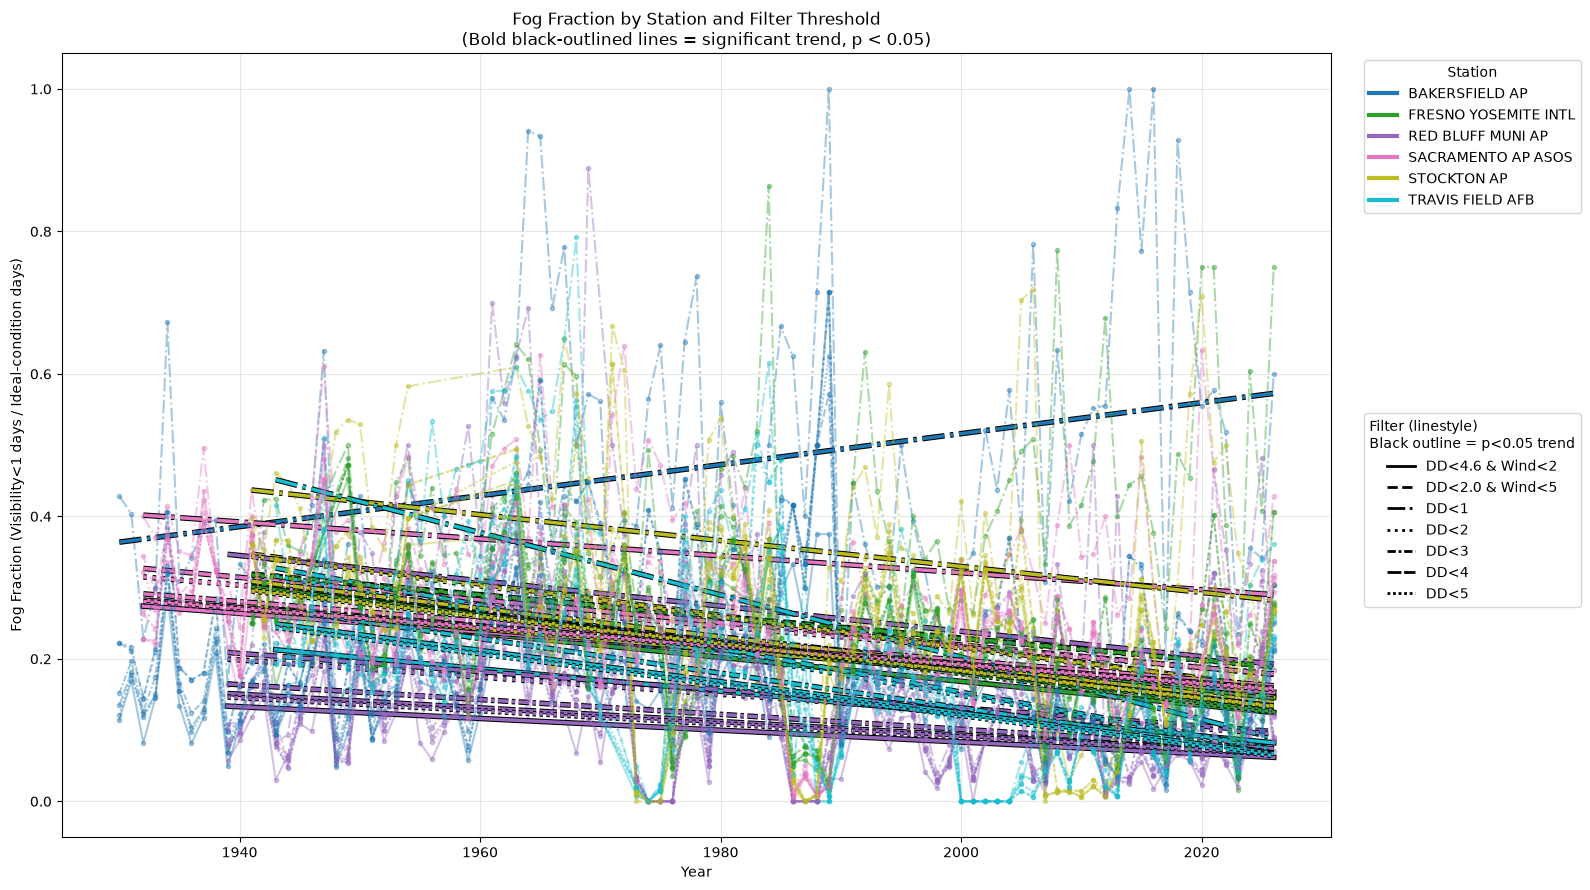

,filter,STATION,slope_per_year,p_value,significant
17,DD<1,TRAVIS FIELD AFB,-0.004369,4.564390e-08,True
12,DD<1,BAKERSFIELD AP,0.002175,2.935308e-03,True
15,DD<1,SACRAMENTO AP ASOS,-0.001188,8.466685e-03,True
14,DD<1,RED BLUFF MUNI AP,-0.001773,2.046640e-02,True
16,DD<1,STOCKTON AP,-0.001819,3.659878e-02,True
13,DD<1,FRESNO YOSEMITE INTL,0.001039,1.626043e-01,False
23,DD<2,TRAVIS FIELD AFB,-0.002936,2.774146e-07,True
21,DD<2,SACRAMENTO AP ASOS,-0.001447,2.210925e-06,True
22,DD<2,STOCKTON AP,-0.002184,2.425168e-04,True
19,DD<2,FRESNO YOSEMITE INTL,-0.001514,4.888790e-04,True


In [138]:
# Total fog days (visibility < 1) divided by ideal-condition days, per station and per filter,
# plotted together with station = color and filter = linestyle.
# Significant (p < 0.05) linear trends are overlaid as dashed black-outlined lines.

filters_for_ratio = {
    "DD<4.6 & Wind<2": CV_rows_selected_dd_wind_filtered,
    "DD<2.0 & Wind<5": CV_rows_selected_dd_wind5_filtered,
    "DD<1": CV_rows_selected_dd_filtered_1deg,
    "DD<2": CV_rows_selected_dd_filtered_2deg,
    "DD<3": CV_rows_selected_dd_filtered_3deg,
    "DD<4": CV_rows_selected_dd_filtered_4deg,
    "DD<5": CV_rows_selected_dd_filtered_5deg,
}

linestyles_cycle = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 1)), (0, (1, 1))]
filter_linestyles = dict(zip(filters_for_ratio.keys(), linestyles_cycle))

station_colors = dict(zip(station_names, plt.cm.tab10(np.linspace(0, 1, len(station_names)))))

fog_ratio_records = []

for filter_name, df_filter in filters_for_ratio.items():
    ideal_days_by_year = (
        df_filter
        .groupby(["STATION", "year"])[["year", "month", "day"]]
        .apply(lambda df: df.drop_duplicates(subset=["year", "month", "day"]).shape[0])
        .reset_index(name="ideal_days")
    )

    fog_actual = df_filter[df_filter["HourlyVisibility"] < 1]

    fog_days_by_year = (
        fog_actual
        .groupby(["STATION", "year"])[["year", "month", "day"]]
        .apply(lambda df: df.drop_duplicates(subset=["year", "month", "day"]).shape[0])
        .reset_index(name="fog_days")
    )

    ratio_df = pd.merge(ideal_days_by_year, fog_days_by_year, on=["STATION", "year"], how="left")
    ratio_df["fog_days"] = ratio_df["fog_days"].fillna(0)
    ratio_df["fog_fraction"] = ratio_df["fog_days"] / ratio_df["ideal_days"]
    ratio_df["filter"] = filter_name

    fog_ratio_records.append(ratio_df)

fog_ratio_all_filters = pd.concat(fog_ratio_records, ignore_index=True)

fig, ax = plt.subplots(figsize=(16, 9))

trend_summary_all = []

for filter_name in filters_for_ratio.keys():
    linestyle = filter_linestyles[filter_name]

    for station in station_names:
        sub = (
            fog_ratio_all_filters[
                (fog_ratio_all_filters["filter"] == filter_name)
                & (fog_ratio_all_filters["STATION"] == station)
            ]
            .dropna(subset=["fog_fraction"])
            .sort_values("year")
        )

        if len(sub) < 3:
            continue

        x = sub["year"].to_numpy()
        y = sub["fog_fraction"].to_numpy()

        color = station_colors[station]

        ax.plot(
            x, y, linestyle=linestyle, marker="o", markersize=3,
            color=color, alpha=0.4,
        )

        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        significant = np.isfinite(p_value) and (p_value < 0.05)

        trend_summary_all.append({
            "filter": filter_name,
            "STATION": station,
            "slope_per_year": slope,
            "p_value": p_value,
            "significant": significant,
        })

        if significant:
            trend_y = slope * x + intercept
            ax.plot(
                x, trend_y, linestyle=linestyle, linewidth=2.5,
                color=color, alpha=1.0,
                path_effects=[
                    __import__("matplotlib.patheffects", fromlist=["withStroke"]).withStroke(linewidth=4, foreground="black")
                ],
            )

trend_summary_all_df = pd.DataFrame(trend_summary_all).sort_values(["filter", "p_value"])

# Legends: station colors and filter linestyles
station_handles = [
    plt.Line2D([0], [0], color=station_colors[st], lw=3, label=st)
    for st in station_names
]
filter_handles = [
    plt.Line2D([0], [0], color="black", lw=2, linestyle=filter_linestyles[f], label=f)
    for f in filters_for_ratio.keys()
]

legend1 = ax.legend(handles=station_handles, title="Station", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.add_artist(legend1)
ax.legend(handles=filter_handles, title="Filter (linestyle)\nBlack outline = p<0.05 trend",
          loc="upper left", bbox_to_anchor=(1.02, 0.55))

ax.set_xlabel("Year")
ax.set_ylabel("Fog Fraction (Visibility<1 days / Ideal-condition days)")
ax.set_title("Fog Fraction by Station and Filter Threshold\n(Bold black-outlined lines = significant trend, p < 0.05)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

trend_summary_all_df

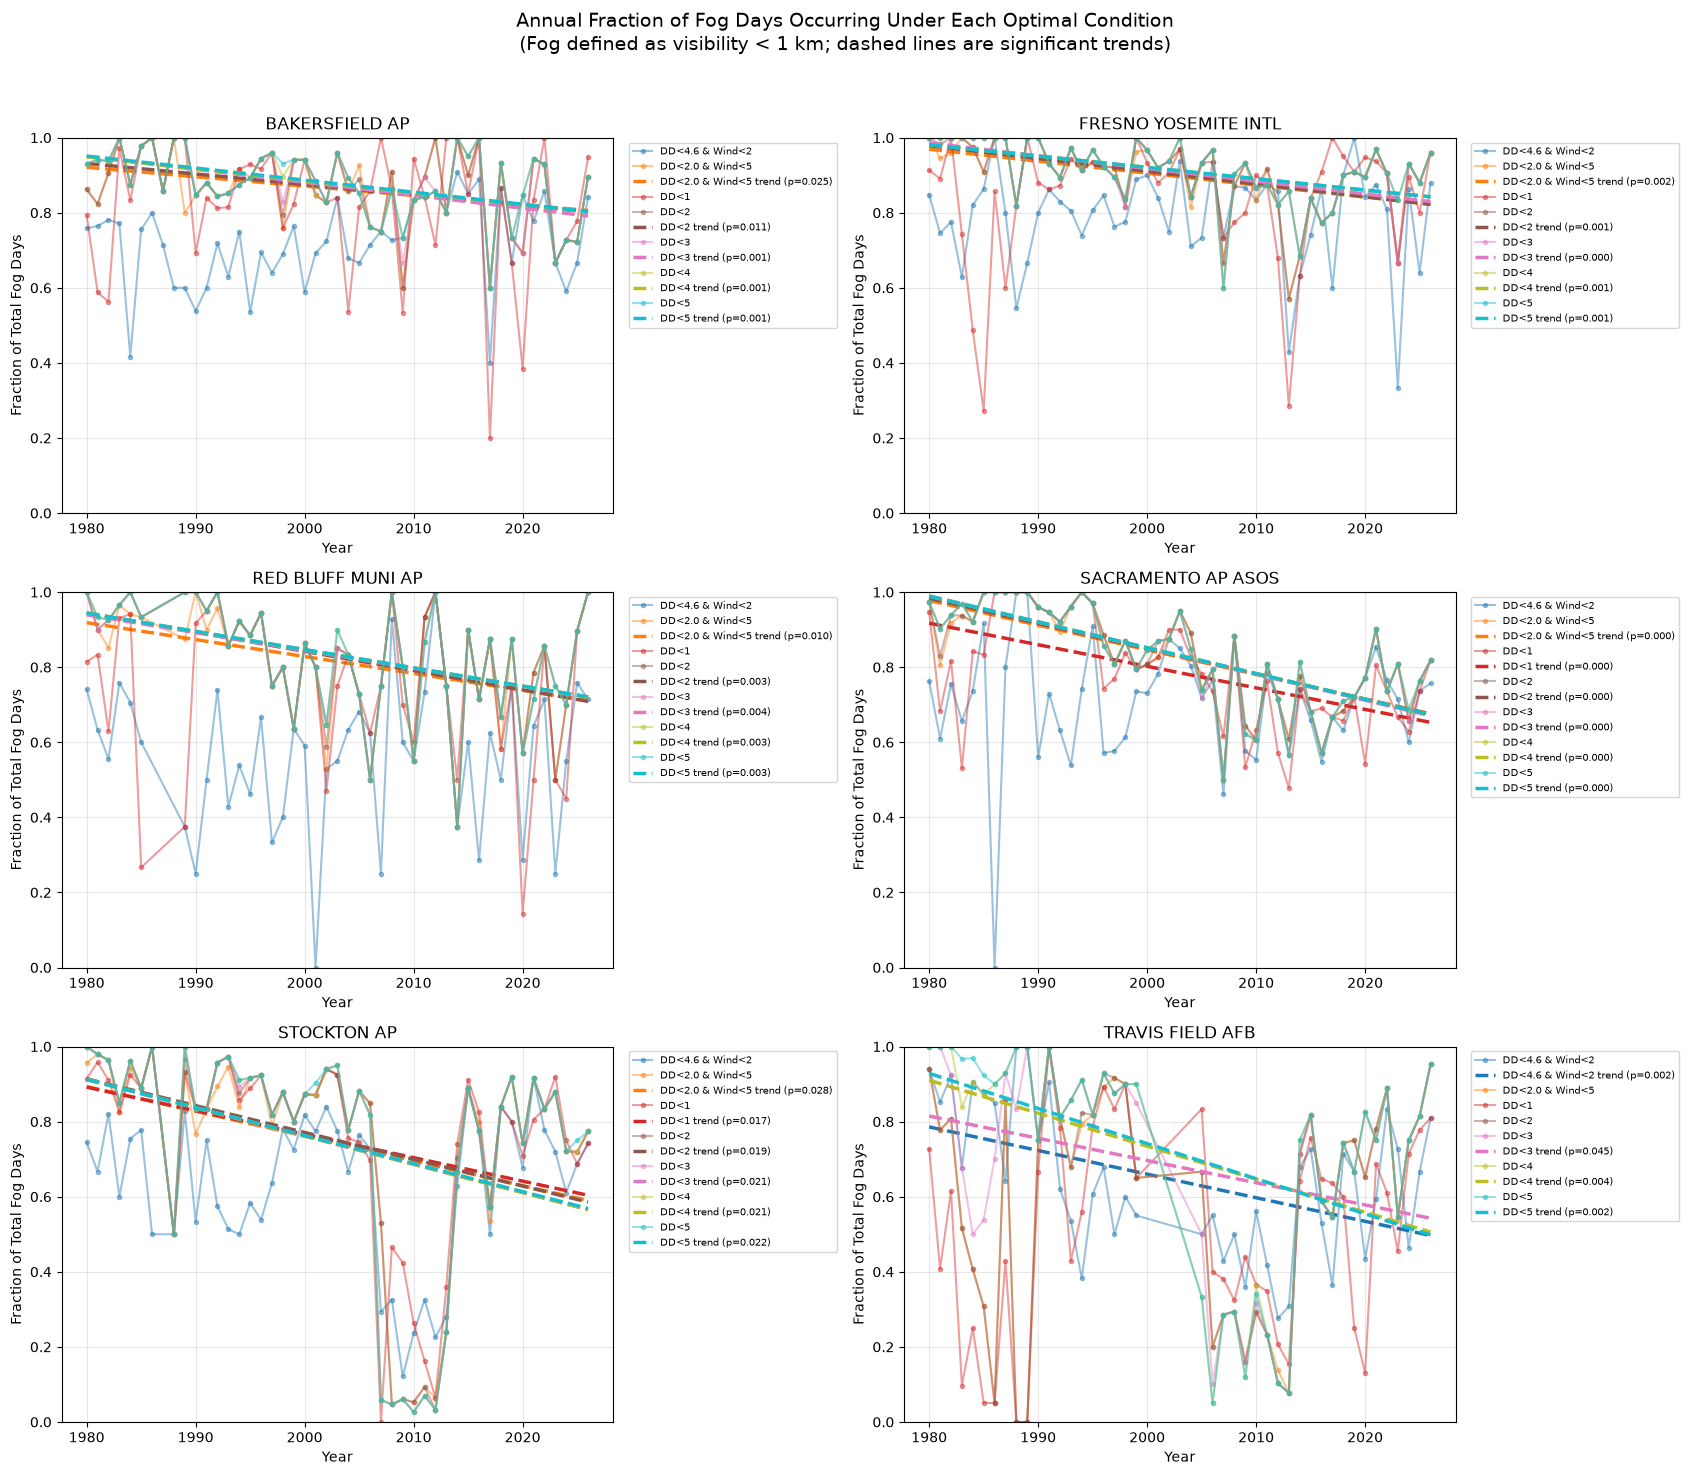

Fog-day fractions:


,STATION,year,total_fog_days,criterion_fog_days,fog_fraction,criterion
546,BAKERSFIELD AP,1980,29,23.0,0.793103,DD<1
819,BAKERSFIELD AP,1980,29,25.0,0.862069,DD<2
273,BAKERSFIELD AP,1980,29,25.0,0.862069,DD<2.0 & Wind<5
1092,BAKERSFIELD AP,1980,29,27.0,0.931034,DD<3
1365,BAKERSFIELD AP,1980,29,27.0,0.931034,DD<4
...,...,...,...,...,...,...
545,TRAVIS FIELD AFB,2026,21,20.0,0.952381,DD<2.0 & Wind<5
1364,TRAVIS FIELD AFB,2026,21,20.0,0.952381,DD<3
1637,TRAVIS FIELD AFB,2026,21,20.0,0.952381,DD<4
272,TRAVIS FIELD AFB,2026,21,17.0,0.809524,DD<4.6 & Wind<2



Significant trends:


,STATION,criterion,slope_per_year,p_value,significant
4,BAKERSFIELD AP,DD<3,-0.003448,8.769716e-04,True
6,BAKERSFIELD AP,DD<5,-0.003216,9.698218e-04,True
5,BAKERSFIELD AP,DD<4,-0.003188,1.062628e-03,True
3,BAKERSFIELD AP,DD<2,-0.002805,1.110609e-02,True
1,BAKERSFIELD AP,DD<2.0 & Wind<5,-0.002497,2.463924e-02,True
11,FRESNO YOSEMITE INTL,DD<3,-0.003393,3.535547e-04,True
12,FRESNO YOSEMITE INTL,DD<4,-0.003019,6.470788e-04,True
13,FRESNO YOSEMITE INTL,DD<5,-0.003019,6.470788e-04,True
10,FRESNO YOSEMITE INTL,DD<2,-0.003399,8.377086e-04,True
8,FRESNO YOSEMITE INTL,DD<2.0 & Wind<5,-0.003190,1.544446e-03,True


In [139]:
# Fog days per year and station under each optimal-condition criterion,
# expressed as a fraction of total fog days (visibility < 1 km).
# Significant linear trends are plotted for each station and criterion.

criteria = {
    "DD<4.6 & Wind<2": CV_rows_selected_dd_wind_filtered,
    "DD<2.0 & Wind<5": CV_rows_selected_dd_wind5_filtered,
    "DD<1": CV_rows_selected_dd_filtered_1deg,
    "DD<2": CV_rows_selected_dd_filtered_2deg,
    "DD<3": CV_rows_selected_dd_filtered_3deg,
    "DD<4": CV_rows_selected_dd_filtered_4deg,
    "DD<5": CV_rows_selected_dd_filtered_5deg,
}

def daily_fog_counts(df):
    fog = df[
        (df["HourlyVisibility"] < 1)
        & (df["year"] >= 1980)
    ][["STATION", "year", "month", "day"]].drop_duplicates()

    return (
        fog.groupby(["STATION", "year"])
        .size()
        .reset_index(name="fog_days")
    )

# Total fog days per station and year
total_fog_days = daily_fog_counts(CV_rows_selected)
total_fog_days = total_fog_days.rename(columns={"fog_days": "total_fog_days"})

records = []

for criterion, criterion_df in criteria.items():
    criterion_fog_days = daily_fog_counts(criterion_df)
    criterion_fog_days = criterion_fog_days.rename(
        columns={"fog_days": "criterion_fog_days"}
    )

    result = pd.merge(
        total_fog_days,
        criterion_fog_days,
        on=["STATION", "year"],
        how="left",
    )

    result["criterion_fog_days"] = result["criterion_fog_days"].fillna(0)
    result["fog_fraction"] = (
        result["criterion_fog_days"] / result["total_fog_days"]
    )
    result["criterion"] = criterion
    records.append(result)

fog_fraction_by_criterion = pd.concat(records, ignore_index=True)

# Individual plot for each station
n_cols = 2
n_rows = int(np.ceil(len(station_names) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(17, 5 * n_rows), sharex=False
)
axes = np.atleast_1d(axes).flatten()

colors = plt.cm.tab10(np.linspace(0, 1, len(criteria)))

trend_records = []

for ax, station in zip(axes, station_names):
    station_data = fog_fraction_by_criterion[
        fog_fraction_by_criterion["STATION"] == station
    ]

    for (criterion, criterion_data), color in zip(
        station_data.groupby("criterion", sort=False), colors
    ):
        criterion_data = criterion_data.sort_values("year")

        if len(criterion_data) < 3:
            continue

        x = criterion_data["year"].to_numpy()
        y = criterion_data["fog_fraction"].to_numpy()

        ax.plot(
            x, y, marker="o", markersize=3, alpha=0.45,
            color=color, label=criterion
        )

        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        significant = np.isfinite(p_value) and p_value < 0.05

        trend_records.append({
            "STATION": station,
            "criterion": criterion,
            "slope_per_year": slope,
            "p_value": p_value,
            "significant": significant,
        })

        if significant:
            ax.plot(
                x, slope * x + intercept,
                linestyle="--", linewidth=2.5, color=color,
                label=f"{criterion} trend (p={p_value:.3f})"
            )

    ax.set_title(station)
    ax.set_xlabel("Year")
    ax.set_ylabel("Fraction of Total Fog Days")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1))

for ax in axes[len(station_names):]:
    ax.set_visible(False)

fig.suptitle(
    "Annual Fraction of Fog Days Occurring Under Each Optimal Condition\n"
    "(Fog defined as visibility < 1 km; dashed lines are significant trends)",
    fontsize=14,
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

fog_trend_summary = (
    pd.DataFrame(trend_records)
    .sort_values(["STATION", "p_value"])
)

print("Fog-day fractions:")
display(fog_fraction_by_criterion.sort_values(["STATION", "year", "criterion"]))

print("\nSignificant trends:")
display(
    fog_trend_summary[fog_trend_summary["significant"]]
)

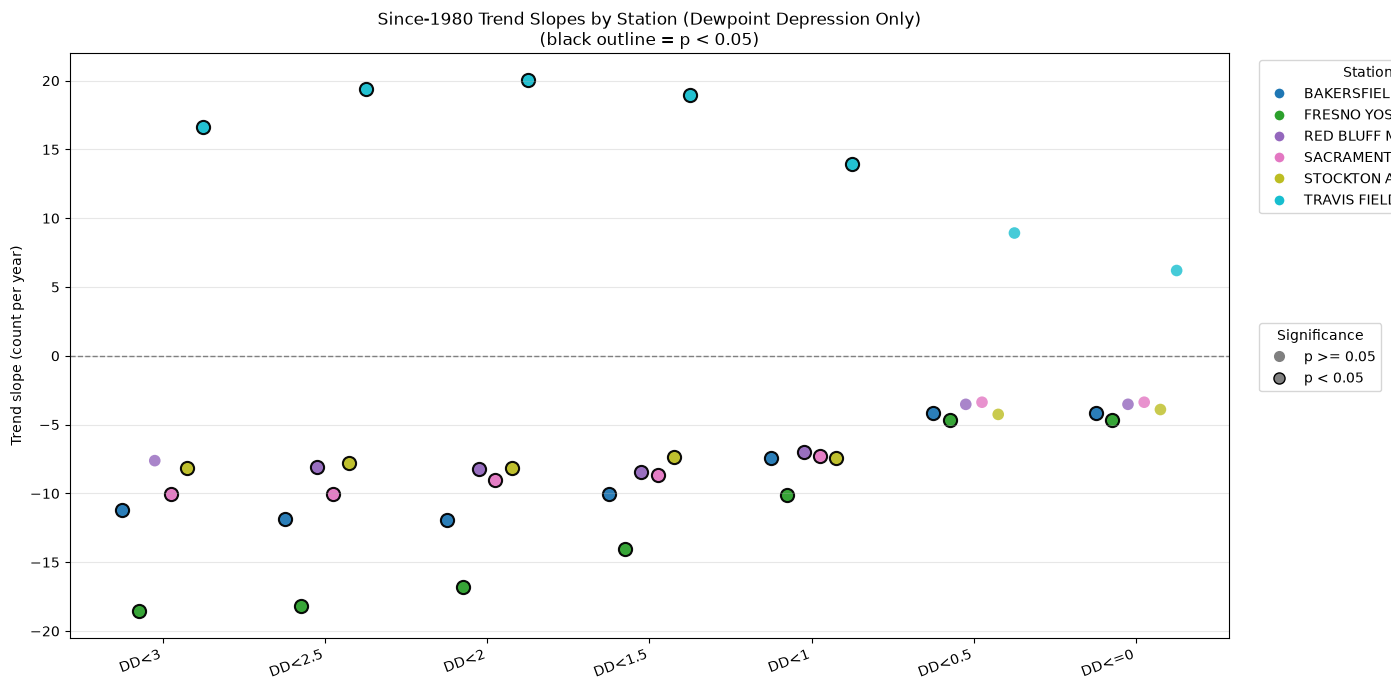

,filter,STATION,slope_per_year,p_value,significant
30,DD<0.5,BAKERSFIELD AP,-4.181545,8.404090e-04,True
31,DD<0.5,FRESNO YOSEMITE INTL,-4.688599,3.170655e-03,True
32,DD<0.5,RED BLUFF MUNI AP,-3.524952,6.806176e-02,False
34,DD<0.5,STOCKTON AP,-4.256244,7.574132e-02,False
35,DD<0.5,TRAVIS FIELD AFB,8.926341,1.089551e-01,False
33,DD<0.5,SACRAMENTO AP ASOS,-3.370722,1.233412e-01,False
25,DD<1,FRESNO YOSEMITE INTL,-10.099098,9.916167e-05,True
24,DD<1,BAKERSFIELD AP,-7.416166,2.209023e-04,True
26,DD<1,RED BLUFF MUNI AP,-7.004764,7.435799e-03,True
29,DD<1,TRAVIS FIELD AFB,13.919635,1.170755e-02,True


In [125]:
# Dewpoint-depression-only trend summary plot since 1980
# Thresholds: <3, <2.5, <2, <1.5, <1, <0.5, and <=0

dd_thresholds = [3.0, 2.5, 2.0, 1.5, 1.0, 0.5]

filters_dd_only = {
    f"DD<{thr:g}": CV_rows_selected[
        CV_rows_selected["HourlyDewpointDepression"] < thr
    ].drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")
    for thr in dd_thresholds
}

filters_dd_only["DD<=0"] = CV_rows_selected[
    CV_rows_selected["HourlyDewpointDepression"] <= 0
].drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")

trend_points_dd_only = []

for filter_name, df_filter in filters_dd_only.items():
    yearly = (
        df_filter[df_filter["year"] >= 1980]
        .groupby(["STATION", "year"])
        .size()
        .reset_index(name="count")
    )

    for st in station_names:
        sd = yearly[yearly["STATION"] == st].sort_values("year")
        if len(sd) < 3:
            continue

        x = sd["year"].to_numpy()
        y = sd["count"].to_numpy()
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        trend_points_dd_only.append(
            {
                "filter": filter_name,
                "STATION": st,
                "slope_per_year": slope,
                "p_value": p_value,
                "significant": bool(np.isfinite(p_value) and (p_value < 0.05)),
            }
        )

trend_points_dd_only_df = pd.DataFrame(trend_points_dd_only)

# Plot (same style as prior trend summary)
fig, ax = plt.subplots(figsize=(14, 7))

filter_order = list(filters_dd_only.keys())
x_map = {f: i for i, f in enumerate(filter_order)}

station_colors = dict(zip(station_names, plt.cm.tab10(np.linspace(0, 1, len(station_names)))))
offsets = np.linspace(-0.25, 0.25, len(station_names))
station_offset = dict(zip(station_names, offsets))

for st in station_names:
    sub = trend_points_dd_only_df[trend_points_dd_only_df["STATION"] == st].copy()
    if sub.empty:
        continue

    sub["x"] = sub["filter"].map(x_map).astype(float) + station_offset[st]

    ns = sub[~sub["significant"]]
    ax.scatter(
        ns["x"], ns["slope_per_year"],
        s=70, color=station_colors[st], alpha=0.8, edgecolors="none"
    )

    sg = sub[sub["significant"]]
    ax.scatter(
        sg["x"], sg["slope_per_year"],
        s=90, color=station_colors[st], alpha=0.95, edgecolors="black", linewidths=1.5
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(range(len(filter_order)))
ax.set_xticklabels(filter_order, rotation=20, ha="right")
ax.set_ylabel("Trend slope (count per year)")
ax.set_title("Since-1980 Trend Slopes by Station (Dewpoint Depression Only)\n(black outline = p < 0.05)")
ax.grid(True, axis="y", alpha=0.3)

station_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label=st,
               markerfacecolor=station_colors[st], markersize=8)
    for st in station_names
]
legend1 = ax.legend(handles=station_handles, title="Station", loc="upper left", bbox_to_anchor=(1.02, 1))
ax.add_artist(legend1)

sig_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label="p >= 0.05",
               markerfacecolor="gray", markeredgecolor="none", markersize=8),
    plt.Line2D([0], [0], marker="o", color="w", label="p < 0.05",
               markerfacecolor="gray", markeredgecolor="black", markersize=8),
]
ax.legend(handles=sig_handles, title="Significance", loc="upper left", bbox_to_anchor=(1.02, 0.55))

plt.tight_layout()
plt.show()

trend_points_dd_only_df.sort_values(["filter", "p_value"]).head(30)

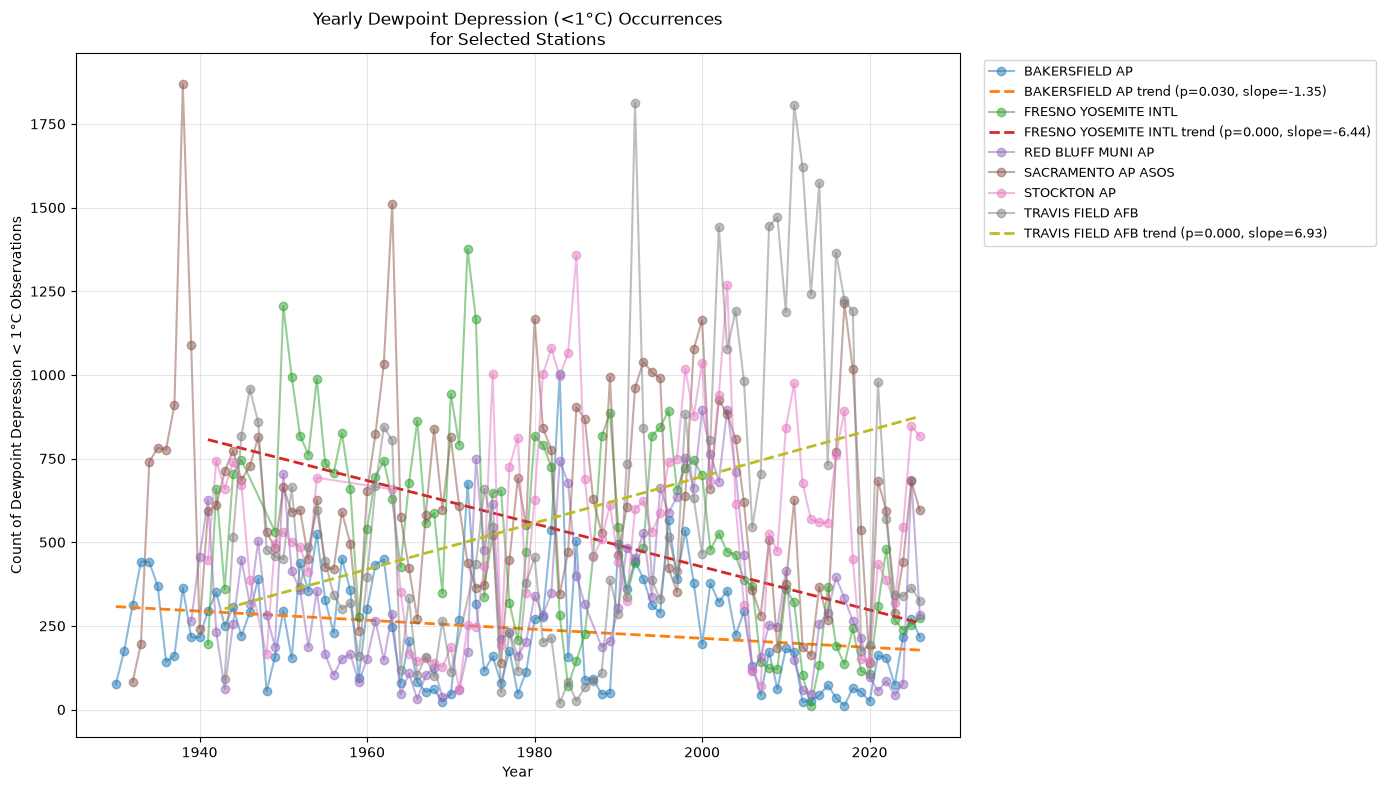

In [126]:
# ------------------------------------------------------------------
# Yearly counts and trend plots for the visibility-based threshold
# ------------------------------------------------------------------
# Use the 1-degree filter as the main "fog occurrence" count
yearly_counts_selected = (
    CV_rows_selected_dd_filtered_1deg.groupby(["STATION", "year"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(14, 8))

for station in station_names:
    station_data = yearly_counts_selected[yearly_counts_selected["STATION"] == station].sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].values
    y = station_data["count"].values

    ax.plot(x, y, marker="o", linestyle="-", alpha=0.5, label=f"{station}")

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    if p_value < 0.05:
        trend_y = slope * x + intercept
        ax.plot(
            x, trend_y, linestyle="--", linewidth=2,
            label=f"{station} trend (p={p_value:.3f}, slope={slope:.2f})"
        )

ax.set_xlabel("Year")
ax.set_ylabel("Count of Dewpoint Depression < 1°C Observations")
ax.set_title(
    "Yearly Dewpoint Depression (<1°C) Occurrences\nfor Selected Stations"
)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

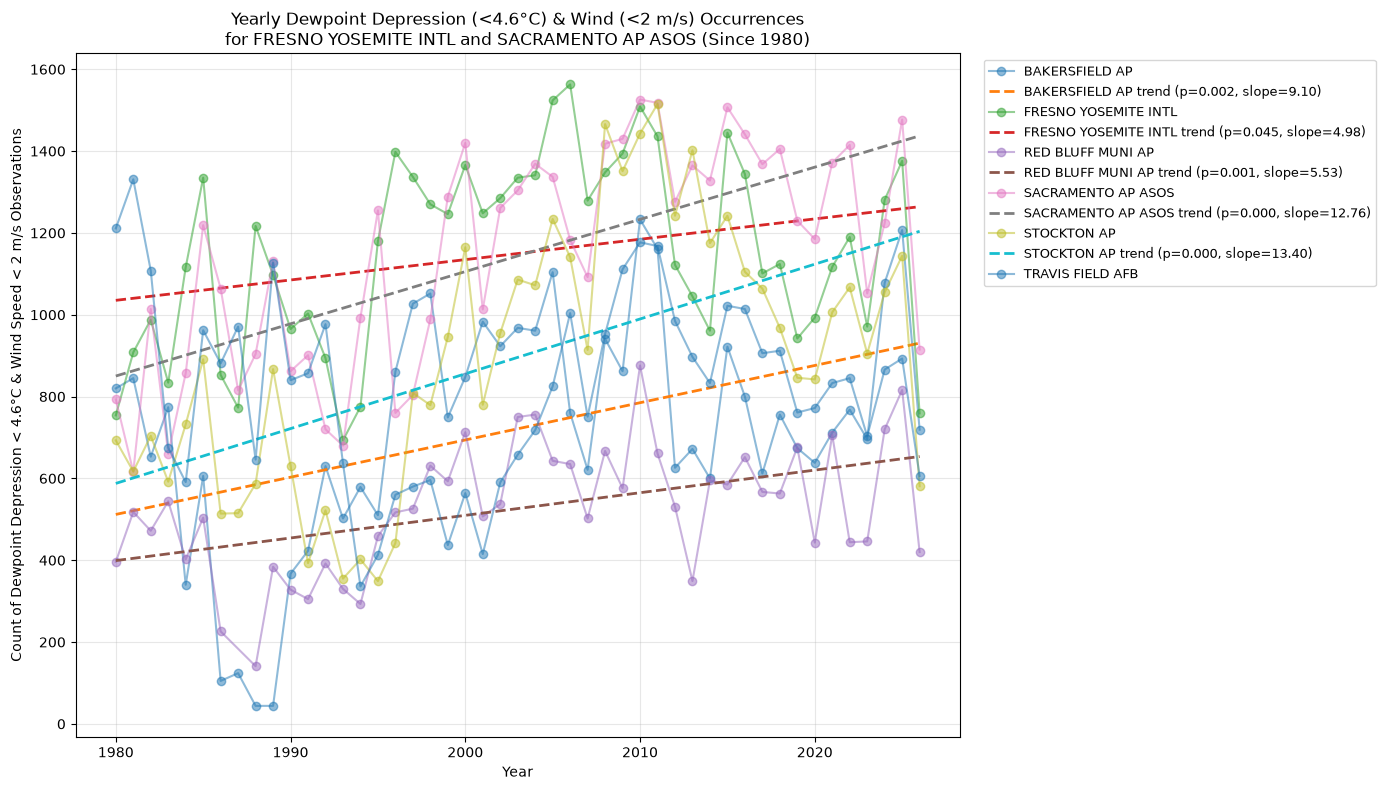


Total observations (selected stations): 2269546
Observations with optimal fog conditions (DD < 4.6 & wind < 2 m/s): 419624
Percentage of optimal fog condition observations: 18.49%

Total unique days in selected data: 19979
Unique days with at least one optimal fog condition observation: 14319
Percentage of days with optimal fog conditions: 71.67%

Optimal-fog rows with visibility < 1 km: 40706 / 419624 = 9.70%
Optimal-fog days with visibility < 1 km: 4991 / 14319 = 34.86%

Station-level optimal fog summaries:

BAKERSFIELD AP
  Total obs: 386295
  Optimal obs: 70355 (18.21%)
  Total days: 14829
  Optimal days: 11170 (75.33%)

FRESNO YOSEMITE INTL
  Total obs: 363973
  Optimal obs: 89259 (24.52%)
  Total days: 12512
  Optimal days: 11037 (88.21%)

RED BLUFF MUNI AP
  Total obs: 359261
  Optimal obs: 39643 (11.03%)
  Total days: 19678
  Optimal days: 8121 (41.27%)

SACRAMENTO AP ASOS
  Total obs: 403780
  Optimal obs: 90531 (22.42%)
  Total days: 14310
  Optimal days: 11512 (80.45%)

STO

In [127]:
# ------------------------------------------------------------------
# Yearly counts and trend plots for the wind-filtered analysis
# ------------------------------------------------------------------
yearly_counts_selected_wind = (
    CV_rows_selected_dd_wind_filtered[CV_rows_selected_dd_wind_filtered["year"] >= 1980]
    .groupby(["STATION", "year"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(14, 8))

for station in station_names:
    station_data = yearly_counts_selected_wind[yearly_counts_selected_wind["STATION"] == station].sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].values
    y = station_data["count"].values

    ax.plot(x, y, marker="o", linestyle="-", alpha=0.5, label=f"{station}")

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    if p_value < 0.05:
        trend_y = slope * x + intercept
        ax.plot(
            x, trend_y, linestyle="--", linewidth=2,
            label=f"{station} trend (p={p_value:.3f}, slope={slope:.2f})"
        )

ax.set_xlabel("Year")
ax.set_ylabel("Count of Dewpoint Depression < 4.6°C & Wind Speed < 2 m/s Observations")
ax.set_title(
    "Yearly Dewpoint Depression (<4.6°C) & Wind (<2 m/s) Occurrences\nfor FRESNO YOSEMITE INTL and SACRAMENTO AP ASOS (Since 1980)"
)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Optimal fog summary for the selected stations
# ------------------------------------------------------------------
total_obs_selected = CV_rows_selected.shape[0]
optimal_obs_selected = CV_rows_selected_dd_wind_filtered.shape[0]

print(f"\nTotal observations (selected stations): {total_obs_selected}")
print(f"Observations with optimal fog conditions (DD < 4.6 & wind < 2 m/s): {optimal_obs_selected}")
print(f"Percentage of optimal fog condition observations: {optimal_obs_selected / total_obs_selected * 100:.2f}%")

optimal_days_selected = CV_rows_selected_dd_wind_filtered[["year", "month", "day"]].drop_duplicates().shape[0]
total_days_selected = CV_rows_selected[["year", "month", "day"]].drop_duplicates().shape[0]

print(f"\nTotal unique days in selected data: {total_days_selected}")
print(f"Unique days with at least one optimal fog condition observation: {optimal_days_selected}")
print(f"Percentage of days with optimal fog conditions: {optimal_days_selected / total_days_selected * 100:.2f}%")

# Fraction of optimal-fog rows and days with visibility < 1 km
optimal_rows_selected = CV_rows_selected_dd_wind_filtered.copy()
vis_lt_1_rows_selected = optimal_rows_selected[optimal_rows_selected["HourlyVisibility"] < 1].copy()
frac_rows_vis_lt_1_selected = vis_lt_1_rows_selected.shape[0] / optimal_rows_selected.shape[0]

total_optimal_days_selected = optimal_rows_selected[["year", "month", "day"]].drop_duplicates().shape[0]
vis_lt_1_days_selected = vis_lt_1_rows_selected[["year", "month", "day"]].drop_duplicates().shape[0]
frac_days_vis_lt_1_selected = vis_lt_1_days_selected / total_optimal_days_selected

print(f"\nOptimal-fog rows with visibility < 1 km: {vis_lt_1_rows_selected.shape[0]} / {optimal_rows_selected.shape[0]} = {frac_rows_vis_lt_1_selected:.2%}")
print(f"Optimal-fog days with visibility < 1 km: {vis_lt_1_days_selected} / {total_optimal_days_selected} = {frac_days_vis_lt_1_selected:.2%}")

# ------------------------------------------------------------------
# Station-by-station breakdown
# ------------------------------------------------------------------
print("\nStation-level optimal fog summaries:")
for station in station_names:
    df_station = CV_rows_selected[CV_rows_selected["STATION"] == station]
    df_opt = CV_rows_selected_dd_wind_filtered[CV_rows_selected_dd_wind_filtered["STATION"] == station]
    total_obs = df_station.shape[0]
    optimal_obs = df_opt.shape[0]
    optimal_days = df_opt[["year", "month", "day"]].drop_duplicates().shape[0]
    total_days = df_station[["year", "month", "day"]].drop_duplicates().shape[0]
    print(f"\n{station}")
    print(f"  Total obs: {total_obs}")
    print(f"  Optimal obs: {optimal_obs} ({optimal_obs/total_obs*100:.2f}%)")
    print(f"  Total days: {total_days}")
    print(f"  Optimal days: {optimal_days} ({optimal_days/total_days*100:.2f}%)")


Optimal fog condition rows (DD < 1.5 & wind < 5 m/s): (390142, 24)


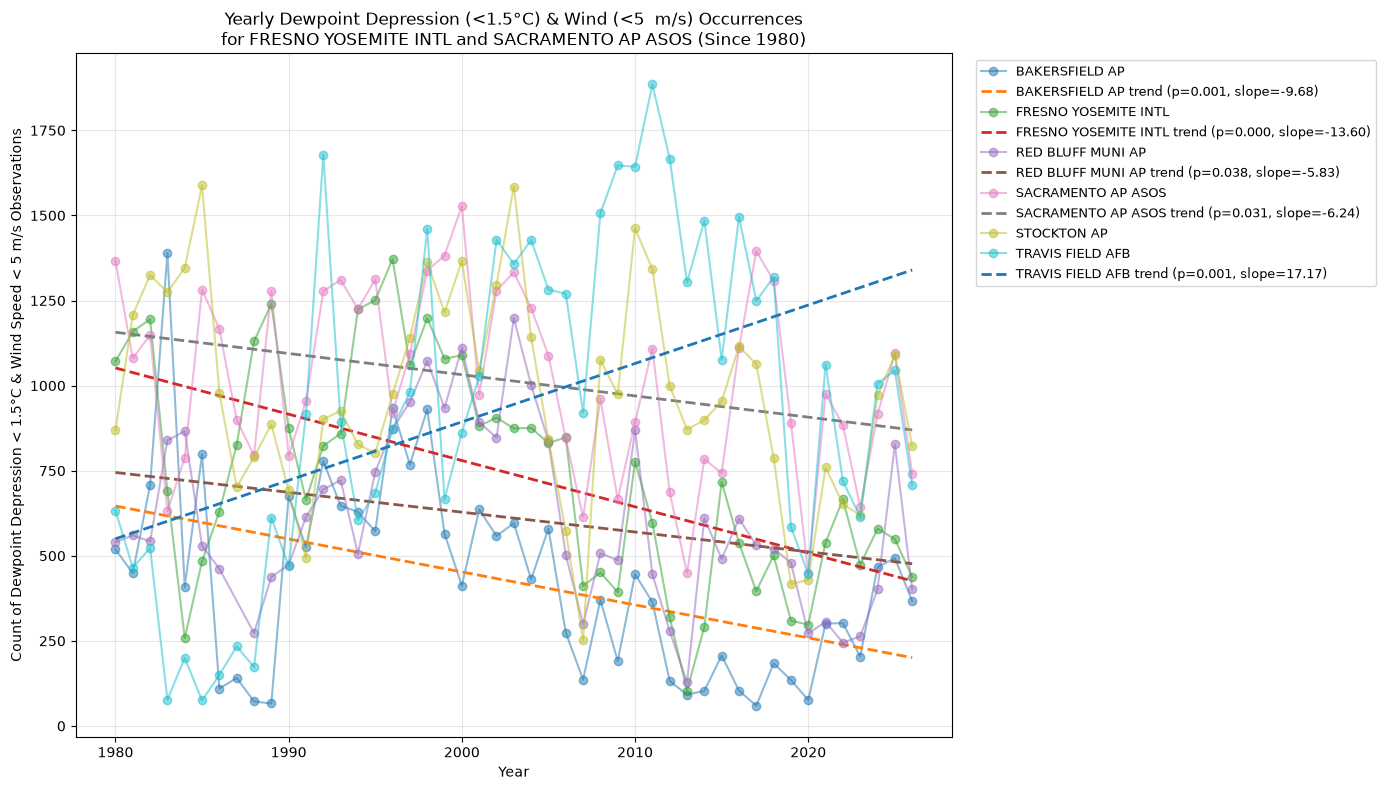

In [128]:
# ------------------------------------------------------------------
# Optimal fog condition filter: dewpoint depression < 4.6 and wind < 2
# ------------------------------------------------------------------
CV_rows_selected_dd_wind_filtered_1 = CV_rows_selected[
    (CV_rows_selected["HourlyDewpointDepression"] < 1.5)
    & (CV_rows_selected["HourlyWindSpeed"] < 5)
].copy()

# remove duplicate hours for the same day and station to avoid overcounting
CV_rows_selected_dd_wind_filtered_1 = CV_rows_selected_dd_wind_filtered_1.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")

print("\nOptimal fog condition rows (DD < 1.5 & wind < 5 m/s):", CV_rows_selected_dd_wind_filtered_1.shape)

# ------------------------------------------------------------------
# Yearly counts and trend plots for the wind-filtered analysis
# ------------------------------------------------------------------
yearly_counts_selected_wind_1 = (
    CV_rows_selected_dd_wind_filtered_1[CV_rows_selected_dd_wind_filtered_1["year"] >= 1980]
    .groupby(["STATION", "year"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(14, 8))

for station in station_names:
    station_data = yearly_counts_selected_wind_1[yearly_counts_selected_wind_1["STATION"] == station].sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].values
    y = station_data["count"].values

    ax.plot(x, y, marker="o", linestyle="-", alpha=0.5, label=f"{station}")

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    if p_value < 0.05:
        trend_y = slope * x + intercept
        ax.plot(
            x, trend_y, linestyle="--", linewidth=2,
            label=f"{station} trend (p={p_value:.3f}, slope={slope:.2f})"
        )

ax.set_xlabel("Year")
ax.set_ylabel("Count of Dewpoint Depression < 1.5°C & Wind Speed < 5 m/s Observations")
ax.set_title(
    "Yearly Dewpoint Depression (<1.5°C) & Wind (<5  m/s) Occurrences\nfor FRESNO YOSEMITE INTL and SACRAMENTO AP ASOS (Since 1980)"
)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Optimal fog condition rows (DD < 4.6): (1077660, 24)


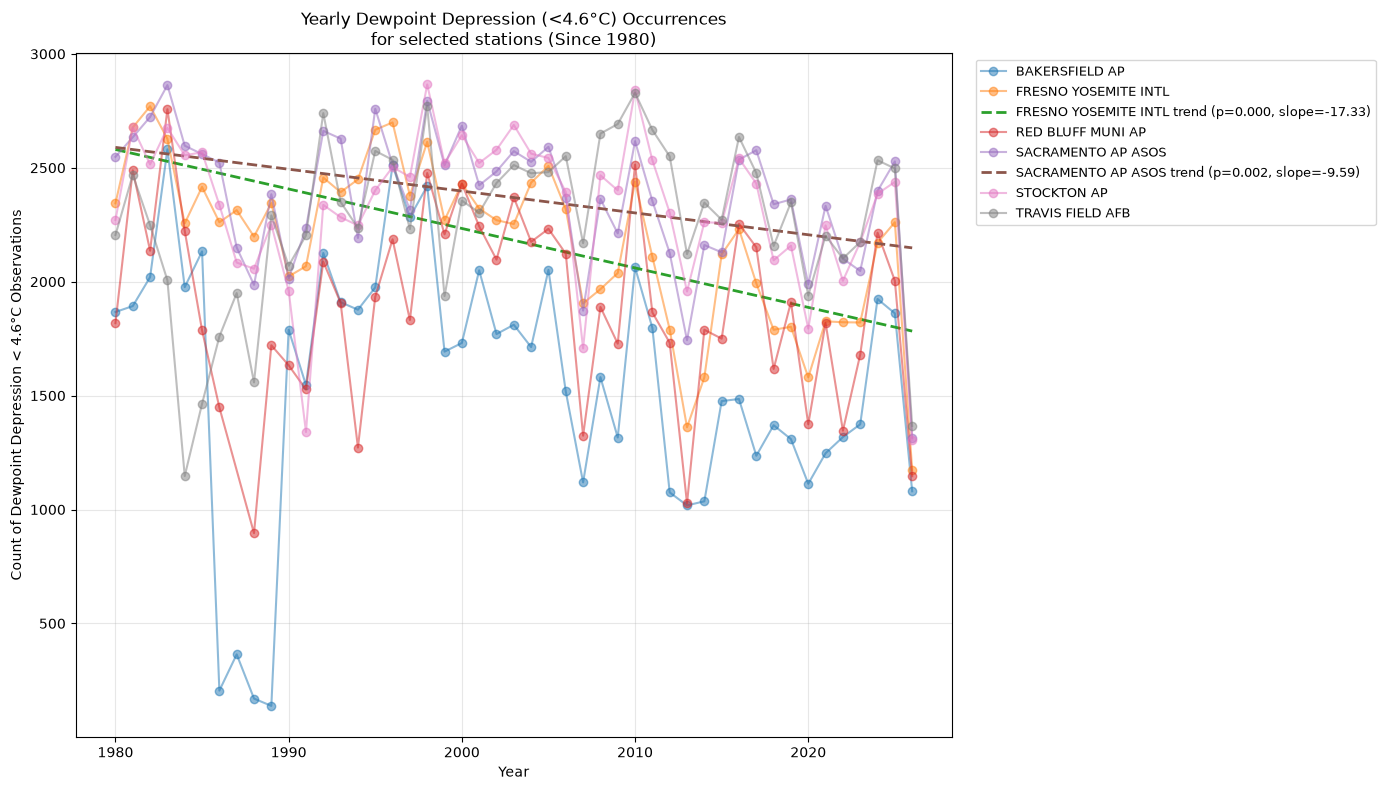

In [129]:
# ------------------------------------------------------------------
# Optimal fog condition filter: dewpoint depression < 4.6 
# ------------------------------------------------------------------
CV_rows_selected_dd_nowind_filtered = CV_rows_selected[CV_rows_selected["HourlyDewpointDepression"] < 4.6].copy()

# remove duplicate hours for the same day and station to avoid overcounting
CV_rows_selected_dd_nowind_filtered = CV_rows_selected_dd_nowind_filtered.drop_duplicates(subset=["STATION", "year", "month", "day", "hour"], keep="first")

print("\nOptimal fog condition rows (DD < 4.6):", CV_rows_selected_dd_nowind_filtered.shape)

# ------------------------------------------------------------------
# Yearly counts and trend plots for the dewpoint depression < 4.6 analysis
# ------------------------------------------------------------------
yearly_counts_selected_dd_nowind = (
    CV_rows_selected_dd_nowind_filtered[CV_rows_selected_dd_nowind_filtered["year"] >= 1980]
    .groupby(["STATION", "year"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(14, 8))

for station in station_names:
    station_data = yearly_counts_selected_dd_nowind[yearly_counts_selected_dd_nowind["STATION"] == station].sort_values("year")

    if len(station_data) < 3:
        continue

    x = station_data["year"].values
    y = station_data["count"].values

    ax.plot(x, y, marker="o", linestyle="-", alpha=0.5, label=f"{station}")

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    if p_value < 0.05:
        trend_y = slope * x + intercept
        ax.plot(
            x, trend_y, linestyle="--", linewidth=2,
            label=f"{station} trend (p={p_value:.3f}, slope={slope:.2f})"
        )

ax.set_xlabel("Year")
ax.set_ylabel("Count of Dewpoint Depression < 4.6°C Observations")
ax.set_title(
    "Yearly Dewpoint Depression (<4.6°C) Occurrences\nfor selected stations (Since 1980)"
)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


          STATION  year  ideal_days  fog_days  fog_fraction
0  BAKERSFIELD AP  1930          96      11.0      0.114583
1  BAKERSFIELD AP  1931         124      21.0      0.169355
2  BAKERSFIELD AP  1932         122      10.0      0.081967
3  BAKERSFIELD AP  1933         110      16.0      0.145455
4  BAKERSFIELD AP  1934         120      35.0      0.291667


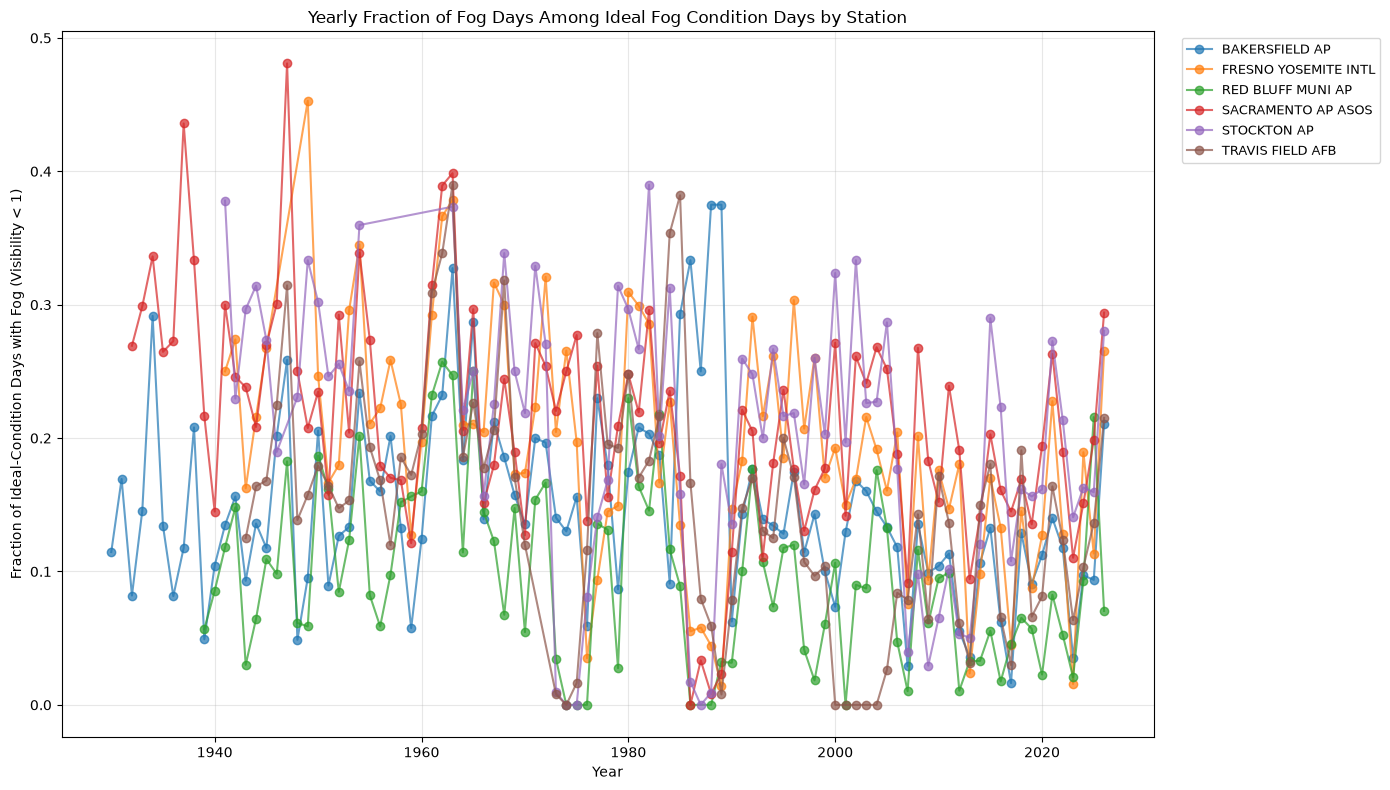

In [130]:
# Compute per-year, per-station counts of ideal fog condition days and
# actual fog days (visibility < 1), then plot the fraction over time.

ideal_days_by_year = (
    CV_rows_selected_dd_wind_filtered
    .groupby(["STATION", "year"])[["year", "month", "day"]]
    .apply(lambda df: df.drop_duplicates(subset=["year", "month", "day"]).shape[0])
    .reset_index(name="ideal_days")
)

fog_actual = CV_rows_selected_dd_wind_filtered[
    CV_rows_selected_dd_wind_filtered["HourlyVisibility"] < 1
]

fog_days_by_year = (
    fog_actual
    .groupby(["STATION", "year"])[["year", "month", "day"]]
    .apply(lambda df: df.drop_duplicates(subset=["year", "month", "day"]).shape[0])
    .reset_index(name="fog_days")
)

fog_ratio_by_year = pd.merge(
    ideal_days_by_year, fog_days_by_year, on=["STATION", "year"], how="left"
)
fog_ratio_by_year["fog_days"] = fog_ratio_by_year["fog_days"].fillna(0)
fog_ratio_by_year["fog_fraction"] = (
    fog_ratio_by_year["fog_days"] / fog_ratio_by_year["ideal_days"]
)

print(fog_ratio_by_year.head())

# ------------------------------------------------------------------
# Plot fog_fraction per year for each station
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

for station in station_names:
    station_data = fog_ratio_by_year[
        fog_ratio_by_year["STATION"] == station
    ].sort_values("year")

    if len(station_data) < 3:
        continue

    ax.plot(
        station_data["year"],
        station_data["fog_fraction"],
        marker="o",
        linestyle="-",
        alpha=0.7,
        label=station,
    )

ax.set_xlabel("Year")
ax.set_ylabel("Fraction of Ideal-Condition Days with Fog (Visibility < 1)")
ax.set_title("Yearly Fraction of Fog Days Among Ideal Fog Condition Days by Station")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Trend summary:
                STATION  n_years  slope_per_year  intercept   r_value  \
1  FRESNO YOSEMITE INTL       83       -0.001683   3.533883 -0.471731   
3    SACRAMENTO AP ASOS       95       -0.001286   2.758041 -0.424780   
5      TRAVIS FIELD AFB       82       -0.001573   3.269381 -0.424447   
4           STOCKTON AP       77       -0.001455   3.093351 -0.355446   
2     RED BLUFF MUNI AP       87       -0.000826   1.735559 -0.321657   
0        BAKERSFIELD AP       97       -0.000486   1.110109 -0.189588   

    p_value   std_err  significant_p_lt_0_05  
1  0.000007  0.000349                   True  
3  0.000018  0.000284                   True  
5  0.000071  0.000375                   True  
4  0.001512  0.000442                   True  
2  0.002382  0.000264                   True  
0  0.062896  0.000258                  False  

Significant trends (p < 0.05):
                STATION  n_years  slope_per_year  intercept   r_value  \
1  FRESNO YOSEMITE INTL       83       

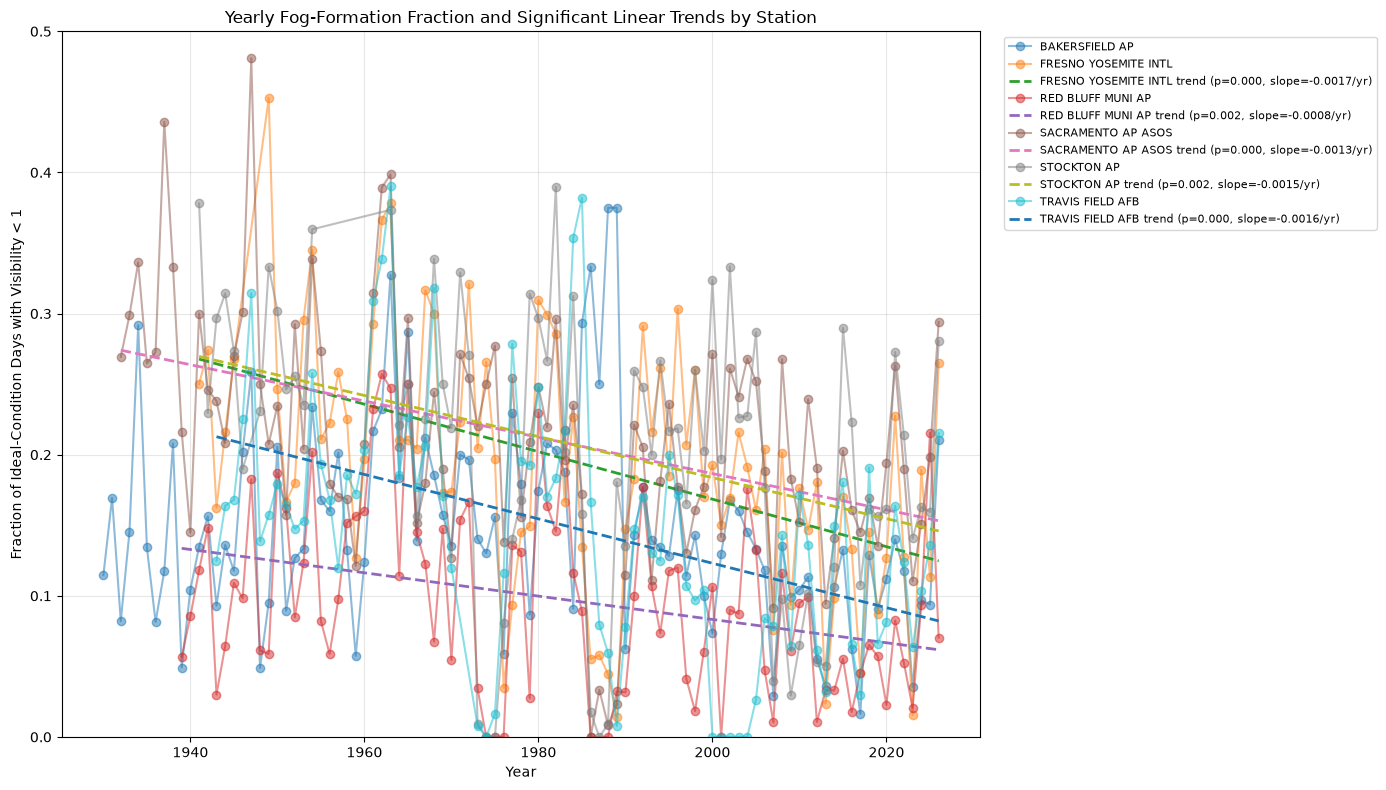

In [131]:
# Trend analysis: fraction of ideal-condition days with visibility < 1 by station
# Uses fog_ratio_by_year from earlier cells (columns: STATION, year, ideal_days, fog_days, fog_fraction)

trend_rows = []

fig, ax = plt.subplots(figsize=(14, 8))

for station in station_names:
    station_data = (
        fog_ratio_by_year[fog_ratio_by_year["STATION"] == station]
        .sort_values("year")
        .copy()
    )

    # keep valid fraction rows only
    station_data = station_data[np.isfinite(station_data["fog_fraction"])]

    if len(station_data) < 3:
        continue

    x = station_data["year"].to_numpy()
    y = station_data["fog_fraction"].to_numpy()

    # plot yearly fraction
    ax.plot(x, y, marker="o", linestyle="-", alpha=0.5, label=f"{station}")

    # linear trend
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    significant = np.isfinite(p_value) and (p_value < 0.05)

    trend_rows.append(
        {
            "STATION": station,
            "n_years": len(station_data),
            "slope_per_year": slope,
            "intercept": intercept,
            "r_value": r_value,
            "p_value": p_value,
            "std_err": std_err,
            "significant_p_lt_0_05": significant,
        }
    )

    # plot only significant trend lines
    if significant:
        trend_y = slope * x + intercept
        ax.plot(
            x, trend_y, linestyle="--", linewidth=2,
            label=f"{station} trend (p={p_value:.3f}, slope={slope:.4f}/yr)"
        )

trend_summary = pd.DataFrame(trend_rows).sort_values("p_value")
print("Trend summary:")
print(trend_summary)

print("\nSignificant trends (p < 0.05):")
print(trend_summary[trend_summary["significant_p_lt_0_05"]])

ax.set_xlabel("Year")
ax.set_ylabel("Fraction of Ideal-Condition Days with Visibility < 1")
ax.set_title("Yearly Fog-Formation Fraction and Significant Linear Trends by Station")
ax.set_ylim(0, 0.5)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

plt.tight_layout()
plt.show()

                STATION  n_years  slope_per_year   p_value  \
0        BAKERSFIELD AP       47       -0.003213  0.000063   
2     RED BLUFF MUNI AP       46       -0.001323  0.040930   
5      TRAVIS FIELD AFB       47       -0.001827  0.044131   
1  FRESNO YOSEMITE INTL       47       -0.001655  0.050404   
4           STOCKTON AP       47       -0.001187  0.246183   
3    SACRAMENTO AP ASOS       47        0.000647  0.411480   

   significant_p_lt_0_05  
0                   True  
2                   True  
5                   True  
1                  False  
4                  False  
3                  False  


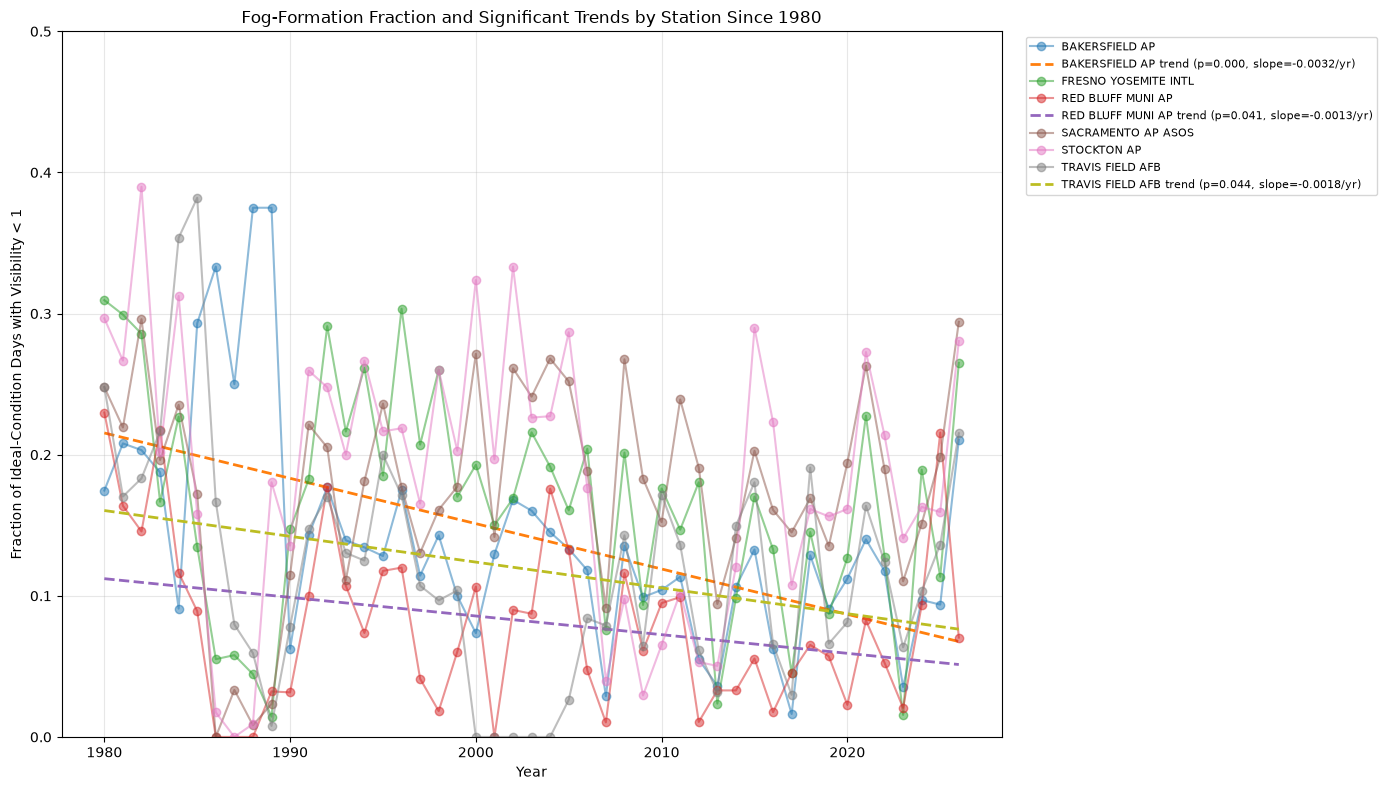

In [132]:
# Trend analysis since 1980: fraction of ideal-condition days with visibility < 1

trend_rows_since_1980 = []

fig, ax = plt.subplots(figsize=(14, 8))

for station in station_names:
    station_data_since_1980 = (
        fog_ratio_by_year[
            (fog_ratio_by_year["STATION"] == station)
            & (fog_ratio_by_year["year"] >= 1980)
        ]
        .dropna(subset=["fog_fraction"])
        .sort_values("year")
    )

    if len(station_data_since_1980) < 3:
        continue

    x = station_data_since_1980["year"].to_numpy()
    y = station_data_since_1980["fog_fraction"].to_numpy()

    ax.plot(x, y, marker="o", linestyle="-", alpha=0.5, label=station)

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    significant = p_value < 0.05

    trend_rows_since_1980.append({
        "STATION": station,
        "n_years": len(station_data_since_1980),
        "slope_per_year": slope,
        "p_value": p_value,
        "significant_p_lt_0_05": significant,
    })

    if significant:
        ax.plot(
            x, slope * x + intercept,
            linestyle="--",
            linewidth=2,
            label=f"{station} trend (p={p_value:.3f}, slope={slope:.4f}/yr)",
        )

trend_summary_since_1980 = pd.DataFrame(trend_rows_since_1980).sort_values("p_value")
print(trend_summary_since_1980)

ax.set_xlabel("Year")
ax.set_ylabel("Fraction of Ideal-Condition Days with Visibility < 1")
ax.set_title("Fog-Formation Fraction and Significant Trends by Station Since 1980")
ax.set_ylim(0, 0.5)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

plt.tight_layout()
plt.show()

                STATION  n_years  slope_per_year   p_value  \
4           STOCKTON AP       30       -0.004032  0.005868   
3    SACRAMENTO AP ASOS       48       -0.001835  0.024019   
1  FRESNO YOSEMITE INTL       36       -0.002360  0.058706   
0        BAKERSFIELD AP       50        0.000818  0.192424   
5      TRAVIS FIELD AFB       35       -0.001046  0.451563   
2     RED BLUFF MUNI AP       41       -0.000377  0.681918   

   significant_p_lt_0_05  
4                   True  
3                   True  
1                  False  
0                  False  
5                  False  
2                  False  


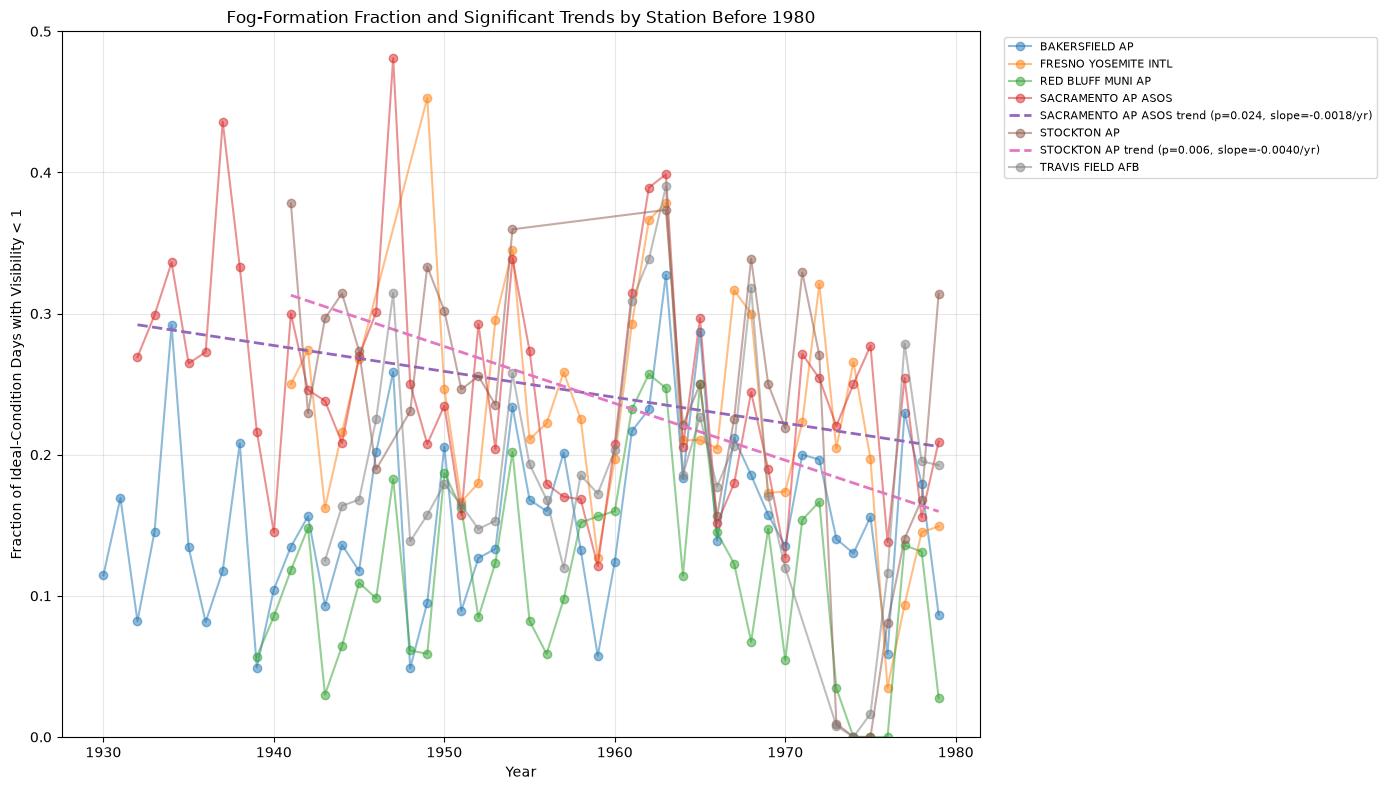

In [133]:
# Trend analysis since 1980: fraction of ideal-condition days with visibility < 1

trend_rows_pre_1980 = []

fig, ax = plt.subplots(figsize=(14, 8))

for station in station_names:
    station_data_pre_1980 = (
        fog_ratio_by_year[
            (fog_ratio_by_year["STATION"] == station)
            & (fog_ratio_by_year["year"] < 1980)
        ]
        .dropna(subset=["fog_fraction"])
        .sort_values("year")
    )

    if len(station_data_pre_1980) < 3:
        continue

    x = station_data_pre_1980["year"].to_numpy()
    y = station_data_pre_1980["fog_fraction"].to_numpy()

    ax.plot(x, y, marker="o", linestyle="-", alpha=0.5, label=station)

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    significant = p_value < 0.05

    trend_rows_pre_1980.append({
        "STATION": station,
        "n_years": len(station_data_pre_1980),
        "slope_per_year": slope,
        "p_value": p_value,
        "significant_p_lt_0_05": significant,
    })

    if significant:
        ax.plot(
            x, slope * x + intercept,
            linestyle="--",
            linewidth=2,
            label=f"{station} trend (p={p_value:.3f}, slope={slope:.4f}/yr)",
        )

trend_summary_pre_1980 = pd.DataFrame(trend_rows_pre_1980).sort_values("p_value")
print(trend_summary_pre_1980)

ax.set_xlabel("Year")
ax.set_ylabel("Fraction of Ideal-Condition Days with Visibility < 1")
ax.set_title("Fog-Formation Fraction and Significant Trends by Station Before 1980")
ax.set_ylim(0, 0.5)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)

plt.tight_layout()
plt.show()

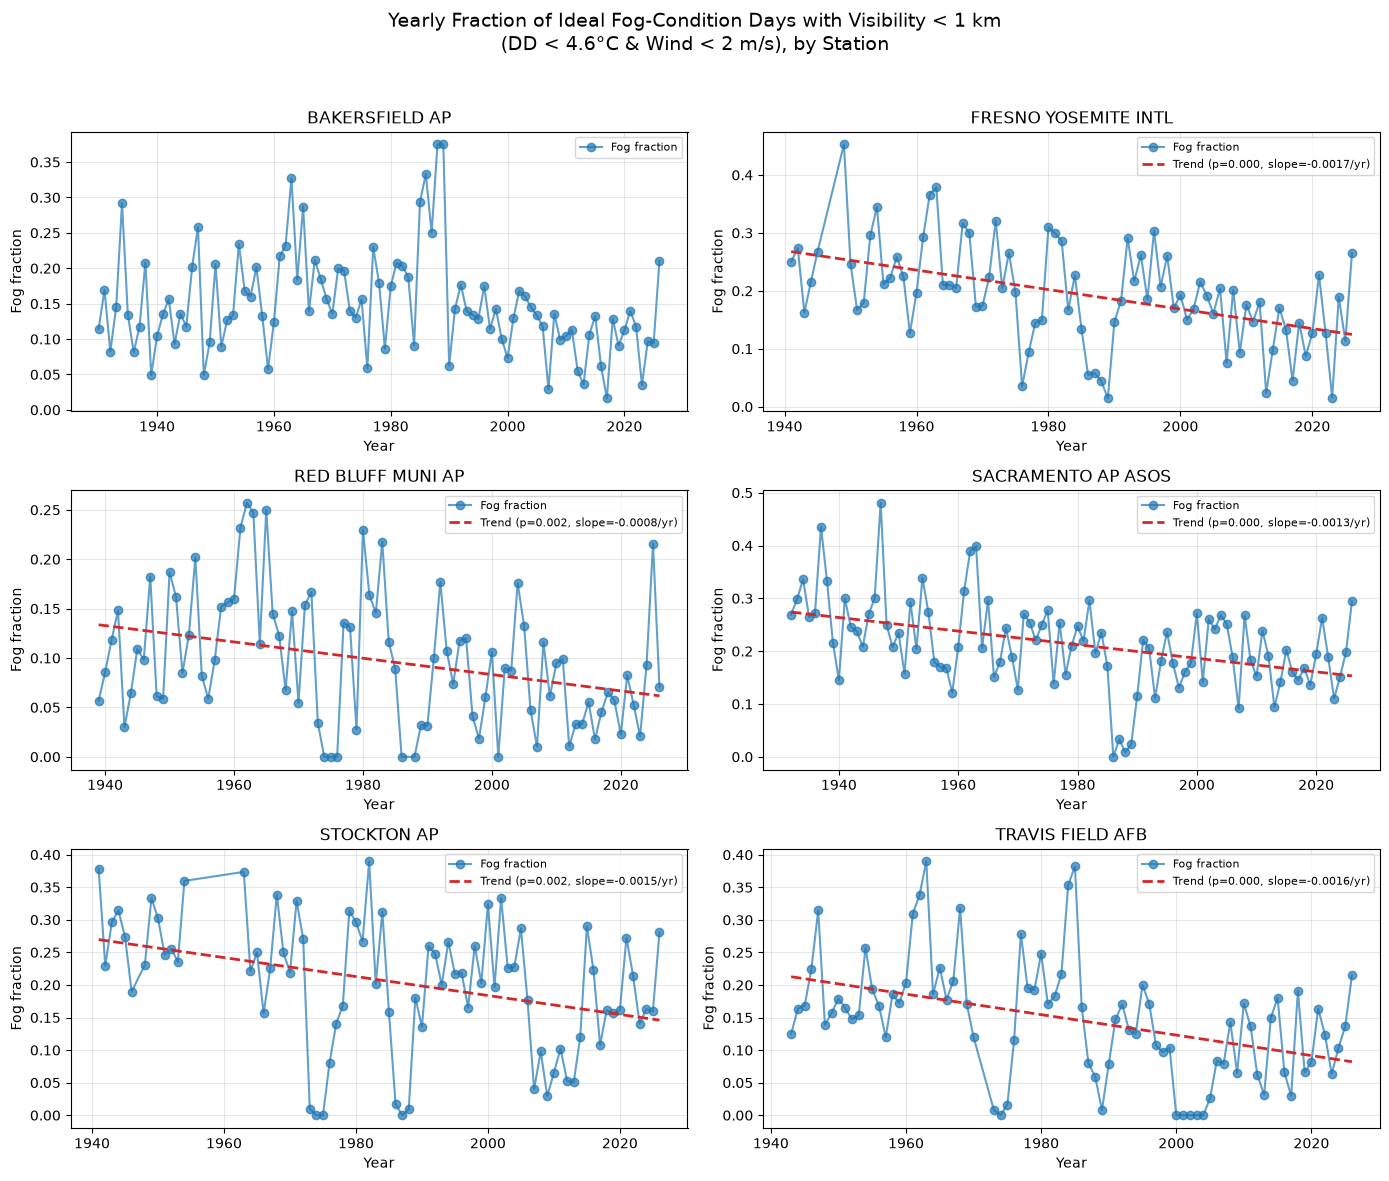

                STATION  n_years  slope_per_year   p_value  \
1  FRESNO YOSEMITE INTL       83       -0.001683  0.000007   
3    SACRAMENTO AP ASOS       95       -0.001286  0.000018   
5      TRAVIS FIELD AFB       82       -0.001573  0.000071   
4           STOCKTON AP       77       -0.001455  0.001512   
2     RED BLUFF MUNI AP       87       -0.000826  0.002382   
0        BAKERSFIELD AP       97       -0.000486  0.062896   

   significant_p_lt_0_05  
1                   True  
3                   True  
5                   True  
4                   True  
2                   True  
0                  False  


In [134]:
# Individual plots per station: fraction of ideal fog-condition days (DD < 4.6 & wind < 2 m/s)
# that actually had fog (visibility < 1 km), with trend lines only where significant (p < 0.05)

n_stations = len(station_names)
n_cols = 2
n_rows = int(np.ceil(n_stations / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharex=False)
axes = axes.flatten()

individual_trend_rows = []

for i, station in enumerate(station_names):
    ax = axes[i]

    station_data = (
        fog_ratio_by_year[fog_ratio_by_year["STATION"] == station]
        .dropna(subset=["fog_fraction"])
        .sort_values("year")
    )

    if len(station_data) < 3:
        ax.set_title(f"{station} (insufficient data)")
        continue

    x = station_data["year"].to_numpy()
    y = station_data["fog_fraction"].to_numpy()

    ax.plot(x, y, marker="o", linestyle="-", alpha=0.7, color="tab:blue", label="Fog fraction")

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    significant = np.isfinite(p_value) and (p_value < 0.05)

    individual_trend_rows.append({
        "STATION": station,
        "n_years": len(station_data),
        "slope_per_year": slope,
        "p_value": p_value,
        "significant_p_lt_0_05": significant,
    })

    if significant:
        trend_y = slope * x + intercept
        ax.plot(
            x, trend_y, linestyle="--", linewidth=2, color="tab:red",
            label=f"Trend (p={p_value:.3f}, slope={slope:.4f}/yr)"
        )

    ax.set_title(station)
    ax.set_xlabel("Year")
    ax.set_ylabel("Fog fraction")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# hide any unused subplots
for j in range(n_stations, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Yearly Fraction of Ideal Fog-Condition Days with Visibility < 1 km\n"
    "(DD < 4.6°C & Wind < 2 m/s), by Station",
    fontsize=14
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

individual_trend_summary = pd.DataFrame(individual_trend_rows).sort_values("p_value")
print(individual_trend_summary)

In [135]:
common_station_names = [
    "BAKERSFIELD AP",
    "FRESNO YOSEMITE INTL",
    "RED BLUFF MUNI AP",
    "SACRAMENTO AP ASOS",
    "STOCKTON AP",
]

fog_rows_common = CV_rows_dd_filtered_1deg[
    CV_rows_dd_filtered_1deg["STATION"].isin(common_station_names)
].copy()

fog_rows_common["date"] = pd.to_datetime(
    fog_rows_common[["year", "month", "day"]]
)

# Summarize each station's fog observations by day
station_day_fog = (
    fog_rows_common
    .groupby(["date", "STATION"])
    .agg(
        first_observation=("DATE", "min"),
        last_observation=("DATE", "max"),
        fog_observations=("STATION", "size"),
    )
    .reset_index()
)

# Find dates affecting at least 5 of the 6 stations
common_fog_events = (
    station_day_fog
    .groupby("date")
    .agg(
        stations_with_fog=("STATION", "nunique"),
        stations=("STATION", lambda x: sorted(x.tolist())),
        total_fog_observations=("fog_observations", "sum"),
    )
    .reset_index()
)

common_fog_events = (
    common_fog_events[
        common_fog_events["stations_with_fog"] >= 5
    ]
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Common fog dates: {len(common_fog_events)}")
common_fog_events

Common fog dates: 166


,date,stations_with_fog,stations,total_fog_observations
0,1942-01-11,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",35
1,1942-01-15,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",30
2,1942-12-15,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",65
3,1942-12-16,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",73
4,1942-12-17,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",60
...,...,...,...,...
161,2026-01-19,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",129
162,2026-01-20,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",86
163,2026-01-21,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",54
164,2026-01-22,5,"[BAKERSFIELD AP, FRESNO YOSEMITE INTL, RED BLU...",83


In [136]:
fog_days_per_year = (
    common_fog_events.assign(
        year=pd.to_datetime(common_fog_events["date"]).dt.year
    )
    .groupby("year")
    .size()
    .reset_index(name="fog_days")
)

fog_days_per_year

,year,fog_days
0,1942,5
1,1944,1
2,1945,3
3,1949,1
4,1950,3
5,1951,3
6,1952,2
7,1953,3
8,1954,16
9,1963,3


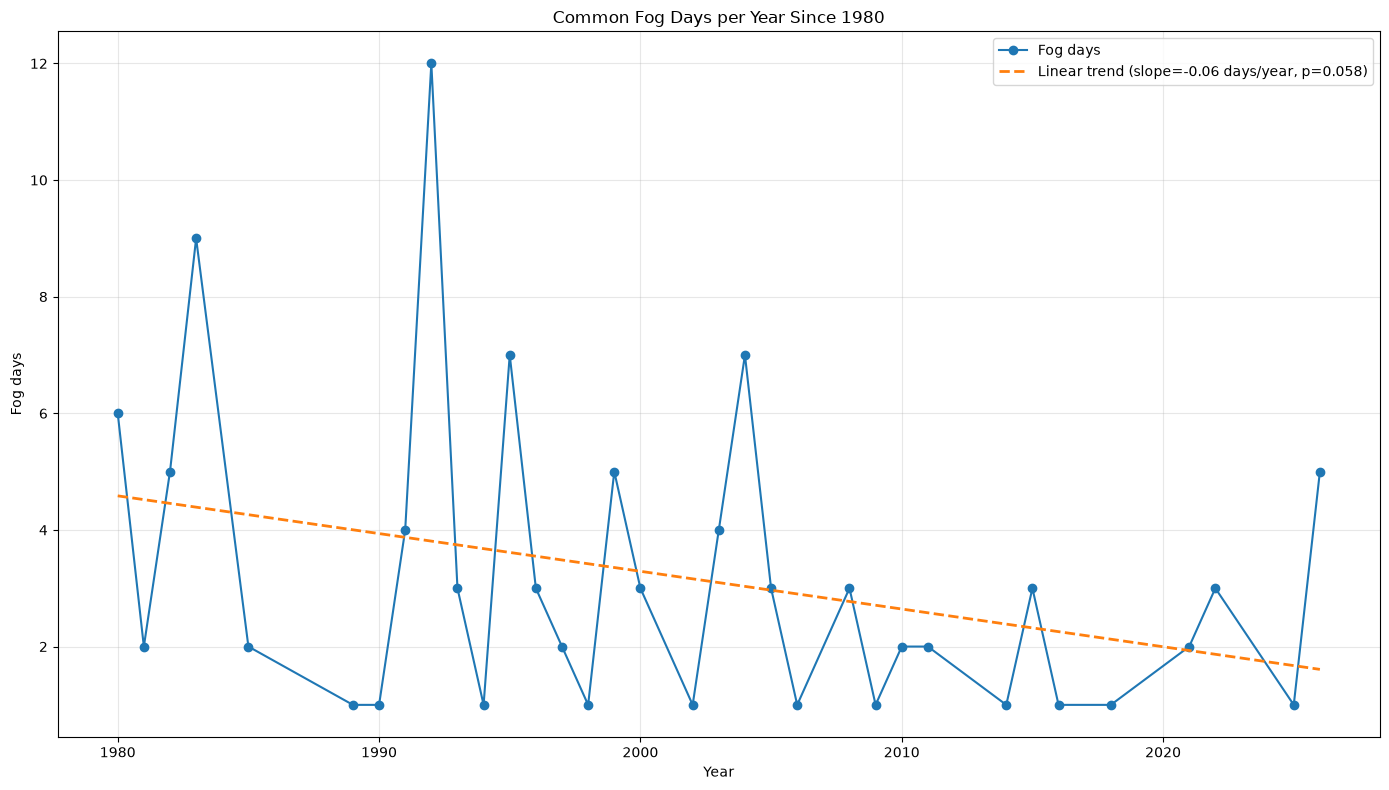

In [137]:
fog_days_since_1980 = fog_days_per_year[
    fog_days_per_year["year"] >= 1980
].sort_values("year")

x_fog = fog_days_since_1980["year"].to_numpy()
y_fog = fog_days_since_1980["fog_days"].to_numpy()

fog_slope, fog_intercept, _, fog_p_value, _ = stats.linregress(x_fog, y_fog)
fog_trend = fog_slope * x_fog + fog_intercept

fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(x_fog, y_fog, marker="o", linestyle="-", label="Fog days")
ax.plot(
    x_fog,
    fog_trend,
    linestyle="--",
    linewidth=2,
    label=f"Linear trend (slope={fog_slope:.2f} days/year, p={fog_p_value:.3f})"
)

ax.set_xlabel("Year")
ax.set_ylabel("Fog days")
ax.set_title("Common Fog Days per Year Since 1980")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()